Created on 14/07/26, from "deter_plan_typdays_gridimport"

Deterministic planning considering the selling of excess electricity to the main grid, and the revenue from powering, partially or totally, the electrical load (previously, the cost of powering the load, and therefore the option/need to buy electricity from the main grid).\
It's a modification of the "full" planning using a typical day formulation.\

This script reflects the model in "Deterministic optimal planning model_MF_260703.pptx".

((I'm still unsure about adding the variable hext to avoid infeasibility in case the hydrogen demand is incompatible with the available renewable production / EL size. I will choose later based on what I need from the final version.\
I added it. The problem becomes slightly slower (from 25 s to 35 s). If needed in future expanded applications, I can remove it. Either way, the results are the same.))

Compared to the previous version:
- Added alternative for EL parameters definition: slope + intercept calculation based on first and last available points (instead of fitting)
- Added reading of parquet file containing the FCR remuneration rates
- Added option to have FCR remuneration rate profiles (previously only fixed values) 

## Multi-energy system deterministic scheduling

### Simple formulation: ideal grid

In [55]:
# pip install --upgrade nbstripout
# pip install pyomo gurobipy

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import gurobipy as gp
import os
from pyomo.environ import *
from pyomo.opt import SolverFactory
from pyomo.core import Var
import copy

from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

# os.environ["GRB_LICENSE_FILE"] = os.environ["HOME"] + "/gurobi/gurobi.lic"

#### Preliminary data gathering
Most of the data is actually defined later, within the definition of the problem itself

In [57]:
#------------------------------------------------------------------------------------------------
# PARAMETERS
# (later they will be redefined to accomodate the typical Pyomo problem formulation)
#------------------------------------------------------------------------------------------------

# GENERAL ---------------------------------------------------------------------------------------
# FCR service
DT_FCR_ramp = 30 / 3600     # time allotted to reach allocated power in FCR service
# Si potrebbe aggiungere un termine (e quindi un vincolo) simile per il tempo di reazione (tempo per raggiungere il 10% del valore di potenza attiva; 
# quello sopra, i 30 s, sono il tempo di risposta). Immagino però che, supponendo le operazioni di ramp-up e ramp-down di natura lineare, il vincolo sul tempo di
# risposta sia sempre il più stringente. La logica è che le norme dovrebbero supporre che i dispositivi sono in grado di variare la propria potenza più lentamente
# nei primi momenti dall'istante in cui ricevono il segnale di comando.
# C_FCR_capup = 20            # remuneration rate for upward FCR capacity bid [€/MW] ### NO REFERENCE ### (Mokhtar will provide this)
# C_FCR_capdown = 20          # remuneration rate for downward FCR capacity bid [€/MW] ### NO REFERENCE ### (Mokhtar will provide this)

# # H2 demand
# C_h2 = 7      # H2 selling price [€/kg]
# Hsup_min_day = 25          # minimum daily hydrogen supply [kg] ### TO DECIDE ###
# Hsup_max_day = 50          # maximum daily hydrogen supply [kg] ### TO DECIDE ###
# Hsup_tgt_week = (Hsup_max_day + Hsup_min_day) / 2 * 7      # target weekly H2 supply (evaluated as daily mean times 7 days) ### TO DECIDE ###
# Hsup_tgt_month = (Hsup_max_day + Hsup_min_day) / 2 * 30    # target monthy H2 supply (evaluated as daily mean times 30 days) ### TO DECIDE ###

# LOADS -----------------------------------------------------------------------------------------
Pl_comm_rtd = 1     # rated commertial load power [MW]
Pl_ind_rtd = 1      # rated industrial load power [MW]
Pl_resid_rtd = 1    # rated residential load power [MW]

# PV --------------------------------------------------------------------------------------------
Ppv_rtd = 3    # PV rated power [MW]

# # BESS ------------------------------------------------------------------------------------------
# Pb_rtd = 1              # BESS rated power [MW]
# Pb_ch_max = Pb_rtd      # BESS maximum charging power [MW]
# Pb_dch_max = Pb_rtd     # BESS maximum discharging power [MW]
# C_rate = 0.5            # BESS C-rate [1/h]
# Eb_rtd = Pb_rtd / C_rate    # BESS rated capacity [MWh]
# DoD = 0.9               # BESS depth of discharge
# SoC_max = 1             # maximum SoC level
# SoC_min = 1 - DoD       # minimum SoC level
# SoC_0 = 0.5 * SoC_max   # SoC value at t=0
# eta_b_rt = 0.931        # battery round-trip efficiency
# eta_b_inv_rt = 0.98     # inverter round-trip efficiency
# eta_bch = np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)       # BESS charging efficiency
# eta_bdch = np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)      # BESS discharging efficiency
# sig_b_sd = 0.001/24          # BESS hourly self-discharge coefficient [-] (CIGRE) (previously 0.01 for tests)

# # HSS -------------------------------------------------------------------------------------------
# H_hss_max = 1e3                 # hydrogen tank capacity [kg]
# H_hss_min = 0.1 * H_hss_max     # minimum hydrogen tank level [kg]
# H_hss_0 = 0.5 * H_hss_max       # H2 level at t=0
# FR_hc_el2hss = 25               # H2 maximum flow rate for the compressor from EL to HSS ### NO REFERENCE ###
# FR_hc_hss2dem = 25              # H2 maximum flow rate for the compressor from EL to HRS (H2 demand) ### NO REFERENCE ###

# sig_hss_sd = 0              # HSS hourly H2 self-discharge coefficient [-] (previously 0.0002 as test)
# sig_hss_ch = 0              # HSS hourly H2 charging losses coefficient [-]
# sig_hss_dch = 0             # HSS hourly H2 discharging losses coefficient [-]
# sig_hc_el2hss = 0           # coefficient of H2 losses for EL to HSS compression stage [-]
# sig_hc_hss2dem = 0          # coefficient of H2 losses for HSS to HRS compression stage [-]

# FC --------------------------------------------------------------------------------------------
# lhv = 33.3e-3       # lower heating value of H2 [MWh/kg]
# eta_fc = 0.5        # FC efficiency

Pfc_rtd = 0.5          # FC rated power [MW]
Pfc_min_ratio = 0.4    # FC minimum power ratio [-] (previously 0.1 for tests) (the sources from which I derived the value 0.4 are not very good)
Pfc_min = Pfc_min_ratio * Pfc_rtd       # FC minimum turndown level [MW] (also minimum power level)
rho_fcpos = 0.07 * Pfc_rtd * 3600    # FC positive ramp rate [MW/h]  (original data 7 kW/s for a 100 kW FC --> 0.07 pu/s) (previously 20*Pfc_rtd for tests)
rho_fcneg = -0.046 * Pfc_rtd * 3600   # FC negative ramp rate [MW/h]  (original data -4.6 kW/s for a 100 kW FC --> -0.046 pu/s) (previously -20*Pfc_rtd for tests)


# COMPRESSORS -----------------------------------------------------------------------------------
# Evaluation of the power requirement for hydrogen compression from EL to HSS, in MW per hour per kg of compressed gas
R = 8.3145          # universal gas constant [J/(mol*K)]
Mm = 2.01568e-3     # molar mass of hydrogen [kg/mol]

T = 70 + 273.15     # EL operating/outlet temperature [K]
T_hss = 70 + 273.15     # HSS hydrogen outlet temperature [K]
p = 30e5            # EL operating/outlet pressure [Pa]
p_hss = 150e5       # pressure in the HSS [Pa]
p_dem = 300e5       # hydrogen delivery pressure [Pa]
eta_cis = 0.75      # isoentropic compressor efficiency (valore indicativo, realistico)

# To clarify the following lines, Zs is evaluated from tables in a reference paper. Assuming compression is performed from 30 bar to 150 bar, I calculated the
# value of Zs by linear interpolation between two known values, 1.02701 (50 bar, 350 K = 76.85 C) and 1.05369 (100 bar, 350 K = 76.85 C). The result is finally
# rounded upward to 1.05.
slope_lin_Zs = (1.05369 - 1.02701) / 50
intercept_lin_Zs = 1.02701 - slope_lin_Zs * 50
Zs = slope_lin_Zs * 90 + intercept_lin_Zs         # compressibility factor of hydrogen at 76.85 C (350 K) [-] (1.048354 ~ 1.05)

ks = 14.427 / 10.302          # average ratio of specific heats (Cp/Cv) for a hydrogen at around 76.85 C (350 K) [-] (The values of Cp and Cv are taken from a reference)

# Notes to interpret the following formula:
# - P_hc will multiply the mass flow of hydrogen produced by the EL
# - Without 3600 and 1e6, the formula evaluates the power consumption for the compression of a kg/s of H2 in J/kg
# - Since we will multiply P_hc by an hydrogen mass flow in kg/h, the division by 3600 is needed
# - The result of the multiplication would then be in J/s = W
# - Finally, the division by 1e6 brings the result to the MW scale
P_hc = (1 / (3600 * Mm * eta_cis)) * Zs * R * T * (ks / (ks - 1)) * ((p_hss / p) ** ((ks - 1) / ks) - 1) / 1e6    # power requirement for the compression of a hydrogen mass unit [MW/kg]


# Evaluation of the power requirement for hydrogen compression from HSS to HRS, in MW per hour per kg of compressed gas
#TODO: Adattare quanto scritto sotto in base ai livelli di pressione di HSS e HRS

# To clarify the following lines, Zs is evaluated from tables in a reference paper. Assuming compression is performed from 30 bar to 150 bar, I calculated the
# value of Zs by linear interpolation between two known values, 1.02701 (50 bar, 350 K = 76.85 C) and 1.05369 (100 bar, 350 K = 76.85 C). The result is finally
# rounded upward to 1.05.
slope_lin_Zs = (1.05369 - 1.02701) / 50
intercept_lin_Zs = 1.02701 - slope_lin_Zs * 50
Zs = slope_lin_Zs * 90 + intercept_lin_Zs         # compressibility factor of hydrogen at 76.85 C (350 K) [-] (1.048354 ~ 1.05)

ks = 14.427 / 10.302          # average ratio of specific heats (Cp/Cv) for a hydrogen at around 76.85 C (350 K) [-] (The values of Cp and Cv are taken from a reference)


# Notes to interpret the following formula:
# - P_hc will multiply the mass flow of hydrogen produced by the EL
# - Without 3600 and 1e6, the formula evaluates the power consumption for the compression of a kg/s of H2 in J/kg
# - Since we will multiply P_hc by an hydrogen mass flow in kg/h, the division by 3600 is needed
# - The result of the multiplication would then be in J/s = W
# - Finally, the division by 1e6 brings the result to the MW scale
P_hc = (1 / (3600 * Mm * eta_cis)) * Zs * R * T * (ks / (ks - 1)) * ((p_hss / p) ** ((ks - 1) / ks) - 1) / 1e6    # power requirement for the compression of a hydrogen mass unit [MW/kg] (previously 0.001 for tests) ### NO REFERENCE ###

The following section is useful to the optimization strategy only in order to find the parameters for the piecewise linear model of the EL hydrogen-power characteristic.

In [58]:
#------------------------------------------------------------------------------------------------
# EL MODEL AND LINEAR APPROXIMATION
#------------------------------------------------------------------------------------------------

# The parameters A and B of the linear EL model, meaning the slope and the intercept of the 
# hydrogen-power characteristic, will be supposed independant of the size of the EL. I'm not sure 
# this is a correct assumption, as the original model is an empirical model with some parameters
# fitted for a specific size (1 MW).
# An alternative to this approach could be to evaluate A and B for different sizes of the EL and
# then deriving the linear relationship between each of them and the size of the EL. Then, the 
# formulation of the problem could probably be modified to account for this. Still, this approach
# may be wrong, lead to unnecessarily complex problem formulation, or both.

# ORIGINAL MODEL --------------------------------------------------------------------------------
# General constants and parameters
T0 = 20 + 273.15    # standard temperature [K]
p0 = 1.01325e5      # standard pressure [Pa]
R = 8.3145          # universal gas constant [J/(mol*K)]
F = 96485           # Faraday constant [C/mol]
z = 2               # number of electrons transferred in electrolysis reaction
Mm = 2.01568e-3     # molar mass of hydrogen [kg/mol]

# Electrolyzer parameters
p = 30e5            # operating pressure [Pa]
T = 70 + 273.15     # operating temperature [K]
R_io = 0.326        # internal stack resistance at standard conditions [Ohm]
k = 0.0395          # fitting parameter
dR_t = -3.812e-3    # temperature coefficient of resistance [Ohm/K]
e_rev0 = 1.476      # reversible voltage at standard conditions [V]
eta_F = 1           # Faraday efficiency

Pel_rtd_W = 1e6         # EL rated power [W]
Pel_min_ratio = 0.1     # EL minimum power ratio [-]
Pel_min_W = Pel_min_ratio * Pel_rtd_W     # EL minimum power [W]
n_s = 275           # number of cells in series
n_p = 3700          # number of cells in parallel
n_tot = n_s * n_p   # total number of cells

# (Empirical) Electrical model
V_rev = e_rev0 + (R*T)/(2*F) * np.log(p/p0)         # reversible voltage [V]
Ri = R_io + k * np.log(p/p0) + dR_t * (T - T0)      

Pel_fit = np.linspace(Pel_min_W, Pel_rtd_W, 901)  # power array for fitting [W]
Pel_fit_cell = Pel_fit / n_tot           # cell power array for fitting [W]

i_fit = (-V_rev + np.sqrt(V_rev**2 + 4*Ri*Pel_fit_cell)) / (2*Ri)      # current array [A]
H2_prod_fit = eta_F * Mm * 3600 * (n_tot * i_fit) / (z * F)            # H2 production rate array for fitting [kg/h]

Pel_rtd = Pel_rtd_W / 1e6                  # EL rated power [MW] (also maximum power)
Pel_min = Pel_min_ratio * Pel_rtd     # EL minimum turndown level [MW] (also minimum power level)

# LINEAR MODEL ----------------------------------------------------------------------------------
lin_param = np.polyfit(Pel_fit, H2_prod_fit, 1)      # fitting parameters of linear model
H2_prod_lin = lin_param[0] * Pel_fit + lin_param[1]  # H2 production rate linear model [kg/h]

# Print results
print('Linear model (fitting)')
print(f"Slope: {lin_param[0]}, Intercept: {lin_param[1]}")

# Adjust parameters to express EL power in MW
a_lin = lin_param[0] * 1e6
b_lin = lin_param[1]


# ALTERNATIVE LINEAR MODEL (slope and intercept calculated from first and last points of the fitting arrays) -----
# x1,y1 = (Pel_min=)Pel_fit[0], H2_prod_fit[0] = 1e5, 2.4366950905325044
# x2,y2 = (Pel_rtd=)Pel_fit[-1], H2_prod_fit[-1] = 1e6, 22.339677050494323
# m = (y2 - y1) / (x2 - x1)
# y = m*x + b => b = y1 - m*x1
slope = (H2_prod_fit[-1] - H2_prod_fit[0]) / (Pel_fit[-1] - Pel_fit[0])
intercept = H2_prod_fit[0] - slope * Pel_fit[0]

print('Linear model (slope + intercept calculation)')
print(f"Slope: {slope}, Intercept: {intercept}")

alt_el_param = False
if alt_el_param:
    a_lin = slope * 1e6
    b_lin = intercept


# ADDITIONAL PARAMETERS ----------------------------------------------------------------------------------------
Pel_sb = 0.02 * Pel_rtd    # EL stand-by power consumption [MW]
rho_elpos = 0.4 * Pel_rtd * 3600    # EL positive ramp rate [MW/h] (original data 0.4 pu/s) (previously 20*Pel_rtd for tests)
rho_elneg = -0.5 * Pel_rtd * 3600   # EL negative ramp rate [MW/h] (original data 0.5 pu/s) (previously 20*Pel_rtd for tests)

# # Evaluation of the ability of the EL to participate to FCR based on its ramp-rate characteristics
# time_maxDPpos = Pel_rtd / rho_elpos   # time needed to ramp up the EL power by a quantity equal to its rated power [h] 
# possible_DP_ratiopos = DT_FCR_ramp / time_maxDPpos   # amount of positive power variation that the EL can achieve in 30 s [p.u. of nominal power]
# time_maxDPneg = Pel_rtd / rho_elneg   # time needed to ramp down the EL power by a quantity equal to its rated power [h] 
# possible_DP_rationeg = DT_FCR_ramp / time_maxDPneg   # amount of negative power variation that the EL can achieve in 30 s [p.u. of nominal power]
# print(f"Time needed for 1 p.u. EL power ramp up: {time_maxDPpos * 3600:.2f} s")
# print(f"Time needed for 1 p.u. EL power ramp down: {time_maxDPneg * 3600:.2f} s")
# print(possible_DP_ratiopos)
# print(possible_DP_rationeg)
# # # The amount of positive (negative) power variation that is possible in the allotted time (30 s) is proportional to the amount of frequency variation we can 
# # # accept while continuing to have the EL participate to the FCR (here called "max_Df_pos(neg)") (through the droop constant -(0.2 Hz / 50 Hz) / (1 pu / 1 pu) = -0.004).
# # band = 0.2    # "regular" band for FCR participation [Hz]
# # max_Df_pos = band * possible_DP_ratiopos
# # max_Df_neg = band * possible_DP_rationeg
# # print(f"Maximum acceptable positive frequency deviation for EL participation to the FCR service: {max_Df_pos:.2f} Hz")
# # print(f"Maximum acceptable negative frequency deviation for EL participation to the FCR service: {max_Df_neg:.2f} Hz")

# # Evaluation of the ability of the FC to participate to FCR based on its ramp-rate characteristics
# time_maxDPpos_fc = Pfc_rtd / rho_fcpos   # time needed to ramp up the EL power by a quantity equal to its rated power [h] 
# possible_DP_ratiopos_fc = DT_FCR_ramp / time_maxDPpos_fc   # amount of positive power variation that the EL can achieve in 30 s [p.u. of nominal power]
# time_maxDPneg_fc = Pfc_rtd / rho_fcneg   # time needed to ramp down the EL power by a quantity equal to its rated power [h] 
# possible_DP_rationeg_fc = DT_FCR_ramp / time_maxDPneg_fc   # amount of negative power variation that the EL can achieve in 30 s [p.u. of nominal power]
# print(f"Time needed for 1 p.u. FC power ramp up: {time_maxDPpos_fc * 3600:.2f} s")
# print(f"Time needed for 1 p.u. FC power ramp down: {time_maxDPneg_fc * 3600:.2f} s")
# print(possible_DP_ratiopos_fc)
# print(possible_DP_rationeg_fc)

Linear model (fitting)
Slope: 2.2084524028207953e-05, Intercept: 0.5145918996345079
Linear model (slope + intercept calculation)
Slope: 2.211442439995758e-05, Intercept: 0.22525265053674648


In [59]:
#------------------------------------------------------------------------------------------------
# PROFILES
#------------------------------------------------------------------------------------------------

# Reading the Excel files
C_ele_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\GME_20240101_20241231_MGP_PrezziZonali_CSUD.xlsx", decimal=',')
# print(C_ele_original)
Pl_Ppv_Pwt_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\Dati ENEA.xlsx")
# print(Pl_Ppv_Pwt_original)


# Extraction of useful profiles
C_ele_full = C_ele_original['€/MWh'].tolist()               # zonal price (CSUD 2024) [€/MWh], from 01/01/24 to 31/12/24 (leap year, 366 days)
C_ele = np.array(C_ele_full[:1416] + C_ele_full[1440:])     # removing 29th Feb data to have 365 days (8760 hours) and turning into ndarray
# C_ele = np.append(C_ele, C_ele[0])                        # make the array go from 0 to 8760 (8761 values)

C_ele_sell = C_ele / 2

Pl_comm_to_arrange = Pl_Ppv_Pwt_original['Commerciale'].tolist()            # commercial load profile [p.u.], from 16/10/20 to 15/10/21
Pl_comm = np.array(Pl_comm_to_arrange[1848:] + Pl_comm_to_arrange[:1848])   # rearranged data from 01/01/21 to 15/10/21 and then from 16/10/20 to 31/12/20

Pl_ind_to_arrange = Pl_Ppv_Pwt_original['Industriale'].tolist()             # industrial load profile [p.u.], from 16/10/20 to 15/10/21
Pl_ind = np.array(Pl_ind_to_arrange[1848:] + Pl_ind_to_arrange[:1848])

Pl_resid_to_arrange = Pl_Ppv_Pwt_original['Residenziale'].tolist()          # residential load profile [p.u.], from 16/10/20 to 15/10/21
Pl_resid = np.array(Pl_resid_to_arrange[1848:] + Pl_resid_to_arrange[:1848])

Ppv_to_arrange = Pl_Ppv_Pwt_original['PV'].tolist()         # PV generation profile [??], from 16/10/20 to 15/10/21
P_pv = np.array(Ppv_to_arrange[1848:] + Ppv_to_arrange[:1848])

Pwt_to_arrange = Pl_Ppv_Pwt_original['Wind'].tolist()       # WT generation profile [??], from 16/10/20 to 15/10/21
P_wt = np.array(Pwt_to_arrange[1848:] + Pwt_to_arrange[:1848])


# Reading the PARQUET file containing the FCR remuneration rate data
FCR_data_path = r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\market_price_measurement_FCR-cap_CH_2022.parquet"
C_FCR_original = pd.read_parquet(FCR_data_path, engine="fastparquet")
# print(C_FCR_original)

# Exporting the dataframe into an Excel file to check the data
# C_FCR_original.to_excel('market_price_measurement_FCR-cap_CH_2022.xlsx', sheet_name='Data Export', index=False)

# Extracting specific columns (max, average, min data)
C_FCR_fullmax = C_FCR_original['max'].tolist()
C_FCR_fullavg = C_FCR_original['avg'].tolist()
# C_FCR_fullmin = C_FCR_original['min'].tolist()

# Selecting only one year (2024) and removing the 29th Feb data to have 365 days (8760 / 4 values)
C_FCR_max4h = np.array(C_FCR_fullmax[4380:4734] + C_FCR_fullmax[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)
C_FCR_avg4h = np.array(C_FCR_fullavg[4380:4734] + C_FCR_fullavg[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)
# C_FCR_min = np.array(C_FCR_fullmin[4380:4734] + C_FCR_fullmin[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)

# Repeating the data to have 1-hour intervals instead of 4-hours ones 
C_FCR_max = np.zeros(8760)
C_FCR_avg = np.zeros(8760)
for t in range(len(C_FCR_max4h)):
    for i in range(4):
        C_FCR_max[4*t + i] = C_FCR_max4h[t]
        C_FCR_avg[4*t + i] = C_FCR_avg4h[t]


# Checking the data -----------------------------------------------------------------------------------
time = np.arange(0, 8760)

# Plot settings
plt.rc('figure', figsize=(20, 20))
plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=11, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 2

"""
# Plots
fig, axs = plt.subplots(8, 1, layout='constrained')
axs[0].plot(time, C_ele, color='blue')
axs[0].set_xlabel('x label')
axs[0].set_ylabel('y label')
axs[0].set_title("Electricity Price [€/MWh]")
axs[0].legend()

axs[1].plot(time, Pl_comm)
axs[1].set_title("Commercial load [p.u.]")
axs[2].plot(time, Pl_ind)
axs[2].set_title("Industrial load [p.u.]")
axs[3].plot(time, Pl_resid)
axs[3].set_title("Residential load [p.u.]")
axs[4].plot(time, P_pv)
axs[4].set_title("PV generation [??]")
axs[5].plot(time, P_wt)
axs[5].set_title("WT generation [??]")
axs[6].plot(time, C_FCR_max)
axs[6].set_title("FCR remuneration rates (max) [€/MWh]")
axs[7].plot(time, C_FCR_avg)
axs[7].set_title("FCR remuneration rates (avg) [€/MWh]")
"""


# Profiles adjustments based on rated powers
Pl_comm = Pl_comm * Pl_comm_rtd         # Commercial load profile [MW]
Pl_ind = Pl_ind * Pl_ind_rtd            # Industrial load profile [MW]
Pl_resid = Pl_resid * Pl_resid_rtd      # Residential load profile [MW]
P_load = Pl_ind + Pl_comm              # load profile used in the optimization problem [MW]
P_pv = (P_pv / 2) * Ppv_rtd             # PV generation profile [MW]
# Pwt = Pwt * Pwt_rtd                   # WT generation profile [MW]

# Scaling the FCR remuneration rates
multiplier_FCR = 1
C_FCR = C_FCR_avg * multiplier_FCR

"""
# Checking the data after adjustments
fig, axs = plt.subplots(6, 1, layout='constrained')
axs[0].plot(time, C_ele, color='blue')
axs[0].set_xlabel('x label')
axs[0].set_ylabel('y label')
axs[0].set_title("Electricity Price [€/MWh]")
axs[0].legend()

axs[1].plot(time, Pl_comm)
axs[1].set_title("Commercial load [MW]")
axs[2].plot(time, Pl_ind)
axs[2].set_title("Industrial load [MW]")
axs[3].plot(time, Pl_resid)
axs[3].set_title("Residential load [MW]")
axs[4].plot(time, P_pv)
axs[4].set_title("PV generation [MW]")
# axs[5].plot(time, P_wt)
# axs[5].set_title("WT generation")
"""

'\n# Checking the data after adjustments\nfig, axs = plt.subplots(6, 1, layout=\'constrained\')\naxs[0].plot(time, C_ele, color=\'blue\')\naxs[0].set_xlabel(\'x label\')\naxs[0].set_ylabel(\'y label\')\naxs[0].set_title("Electricity Price [€/MWh]")\naxs[0].legend()\n\naxs[1].plot(time, Pl_comm)\naxs[1].set_title("Commercial load [MW]")\naxs[2].plot(time, Pl_ind)\naxs[2].set_title("Industrial load [MW]")\naxs[3].plot(time, Pl_resid)\naxs[3].set_title("Residential load [MW]")\naxs[4].plot(time, P_pv)\naxs[4].set_title("PV generation [MW]")\n# axs[5].plot(time, P_wt)\n# axs[5].set_title("WT generation")\n'

In [60]:
#------------------------------------------------------------------------------------------------
# DETERMINING THE TYPICAL DAYS FROM THE ORIGINAL DATASET
#------------------------------------------------------------------------------------------------

# Control panel ---------------------------------------------------------------------------------
# Example: Kmeans + scaling the data --> run_kmeans = True, run_scaledata = True
run_placeholder = False
run_kmeans = True
run_kmedoids = False
run_scaledata = True
# -----------------------------------------------------------------------------------------------

Dnum = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]    # number of real days represented by each typical day (modificare ultimo valore in 30 dopo le prove)
months_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


# PLACEHOLDER: for the moment, I'm extracting actual days in the middle of each month of the year
if run_placeholder:
    # Creating matrices containing the typical days (12 day * 24 hours)
    offset_days = 15
    C_ele_typdays = np.zeros([12, 24])
    C_ele_sell_typdays = np.zeros([12, 24])
    P_load_typdays = np.zeros([12, 24])
    P_pv_typdays = np.zeros([12, 24])
    C_FCR_typdays = np.zeros([12, 24])
    
    # Chosen days (offset_days = 15): 16/01, 15/02, 17/03, ...
    for m in range(0, 12):
        day = 30 * m + offset_days
        C_ele_typdays[m,:] = C_ele[day*24 : day*24+24]
        C_ele_sell_typdays[m,:] = C_ele_sell[day*24 : day*24+24]
        P_load_typdays[m,:] = P_load[day*24 : day*24+24]
        P_pv_typdays[m,:] = P_pv[day*24 : day*24+24]
        C_FCR_typdays[m,:] = C_FCR[day*24 : day*24+24]


# K-Means o K-Medoids
if run_kmeans or run_kmedoids:
    # Preparing the data ------------------------------------------------------
    # Reshaping the (8760, 1) arrays into (365, 24) matrices
    C_ele_mat = np.reshape(copy.copy(C_ele), (365, 24))
    C_ele_sell_mat = np.reshape(copy.copy(C_ele_sell), (365, 24))
    P_load_mat = np.reshape(copy.copy(P_load), (365, 24))
    P_pv_mat = np.reshape(copy.copy(P_pv), (365, 24))
    C_FCR_mat = np.reshape(copy.copy(C_FCR), (365, 24))
    print(C_FCR_mat)

    # Normalizing the data for each type of input
    inputs_tuple = (C_ele_mat, C_ele_sell_mat, P_load_mat, P_pv_mat, C_FCR_mat)
    maximums_list = []
    for input in inputs_tuple:
        maximum = np.max(input)
        maximums_list.append(maximum)    # list of the maximum values for each type of input
        input /= maximum
    print(f'Maximums: {maximums_list}')

    # Connecting the matrices side by side to obtain a single (365, 24*4) matrix
    dataset_for_clustering = np.concatenate((C_ele_mat, C_ele_sell_mat, P_load_mat, P_pv_mat, C_FCR_mat), axis=1)

    # Separating the data by month
    # Dnum = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    dset_jan = dataset_for_clustering[0:31, :]
    dset_feb = dataset_for_clustering[31:59, :]
    dset_mar = dataset_for_clustering[59:90, :]
    dset_apr = dataset_for_clustering[90:120, :]
    dset_may = dataset_for_clustering[120:151, :]
    dset_jun = dataset_for_clustering[151:181, :]
    dset_jul = dataset_for_clustering[181:212, :]
    dset_aug = dataset_for_clustering[212:243, :]
    dset_sep = dataset_for_clustering[243:273, :]
    dset_oct = dataset_for_clustering[273:304, :]
    dset_nov = dataset_for_clustering[304:334, :]
    dset_dec = dataset_for_clustering[334:365, :]

    monthly_data_tuple = (dset_jan, dset_feb, dset_mar, dset_apr, dset_may, dset_jun,
                        dset_jul, dset_aug, dset_sep, dset_oct, dset_nov, dset_dec)

    
    # Clustering to determine the typical days ------------------------------------------------------------
    C_ele_typdays_n = np.zeros([12, 24])
    C_ele_sell_typdays_n = np.zeros([12, 24])
    P_load_typdays_n = np.zeros([12, 24])
    P_pv_typdays_n = np.zeros([12, 24])
    C_FCR_typdays_n = np.zeros([12, 24])

    for m in range(0, 12):
        dset_month = monthly_data_tuple[m]
        
        if run_kmeans:
            km = KMeans(n_clusters=1, random_state=0, n_init="auto").fit(dset_month)
        
        elif run_kmedoids:
            km = KMedoids(n_clusters=1, method='pam', metric='euclidean', random_state=0, max_iter=0).fit(dset_month)

        centr_med_oid = km.cluster_centers_.flatten()
        
        # Separation by data type
        C_ele_typdays_n[m, :] = centr_med_oid[0:24]
        C_ele_sell_typdays_n[m, :] = centr_med_oid[24:48]
        P_load_typdays_n[m, :] = centr_med_oid[48:72]
        P_pv_typdays_n[m, :] = centr_med_oid[72:96]
        C_FCR_typdays_n[m, :] = centr_med_oid[96:120]

        # Manual evaluation of inertia
        manual_iner = 0
        for i in range(len(dset_month[:, 0])):
            manual_iner += sum((centr_med_oid - dset_month[i, :]) ** 2)

        print(f'Inertia for {months_names[m]} = {km.inertia_}')
        print(f'Manually evaluated inertia for {months_names[m]} = {manual_iner}')


    # Post-processing ------------------------------------------------------------------------------
    # De-normalizing the typical day data
    # print(maximums_list)
    C_ele_typdays = C_ele_typdays_n * maximums_list[0]
    C_ele_sell_typdays = C_ele_typdays_n * maximums_list[1]
    P_load_typdays = P_load_typdays_n * maximums_list[2]
    P_pv_typdays = P_pv_typdays_n * maximums_list[3]
    C_FCR_typdays = C_FCR_typdays_n * maximums_list[4]

    # Scaling the data to match yearly generation/consumption/cumulative prices
    if run_scaledata:
        scale_fac_Cele = sum(C_ele) / sum(Dnum[d] * sum(C_ele_typdays[d, :]) for d in range(len(Dnum)))
        scale_fac_Celesell = sum(C_ele_sell) / sum(Dnum[d] * sum(C_ele_sell_typdays[d, :]) for d in range(len(Dnum)))
        scale_fac_Pload = sum(P_load) / sum(Dnum[d] * sum(P_load_typdays[d, :]) for d in range(len(Dnum)))
        scale_fac_Ppv = sum(P_pv) / sum(Dnum[d] * sum(P_pv_typdays[d, :]) for d in range(len(Dnum)))
        scale_fac_CFCR = sum(C_FCR) / sum(Dnum[d] * sum(C_FCR_typdays[d, :]) for d in range(len(Dnum)))

        C_ele_typdays = C_ele_typdays * scale_fac_Cele
        C_ele_sell_typdays = C_ele_sell_typdays * scale_fac_Celesell
        P_load_typdays = P_load_typdays * scale_fac_Pload
        P_pv_typdays = P_pv_typdays * scale_fac_Ppv
        C_FCR_typdays = C_FCR_typdays * scale_fac_CFCR

[[19.01981358 19.01981358 19.01981358 ... 14.24422104 14.24422104
  14.24422104]
 [16.12784431 16.12784431 16.12784431 ... 12.13990685 12.13990685
  12.13990685]
 [16.41491683 16.41491683 16.41491683 ... 12.05256154 12.05256154
  12.05256154]
 ...
 [ 7.14767132  7.14767132  7.14767132 ...  7.63730539  7.63730539
   7.63730539]
 [ 7.22255489  7.22255489  7.22255489 ...  6.5993014   6.5993014
   6.5993014 ]
 [18.5014837  18.5014837  18.5014837  ... 23.09713906 23.09713906
  23.09713906]]
Maximums: [277.0, 138.5, 1.422363129999999, 3.633937425, 52.484042695130114]
Inertia for Jan = 29.109564920889454
Manually evaluated inertia for Jan = 29.109564920889447
Inertia for Feb = 25.77837826446398
Manually evaluated inertia for Feb = 25.77837826446398
Inertia for Mar = 38.27183859923883
Manually evaluated inertia for Mar = 38.27183859923882
Inertia for Apr = 35.87311894056599
Manually evaluated inertia for Apr = 35.873118940565995
Inertia for May = 37.78440074796238
Manually evaluated inertia fo

In [61]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (1/4)
#------------------------------------------------------------------------------------------------

# GENERAL PROBLEM PARAMETERS
time_window = 24 * 365            # time window of full year [h]
N_t = 24                      # time window in a single day / number of timesteps in a single day [h]
N_d = 12                    # number of typical days
D_t = 1                           # timestep [h]

sym_fcr = True

discrete_sizes = False
fcr_price_prof = True


#------------------------------------------------------------------------------------------------
# MODEL
#------------------------------------------------------------------------------------------------

m = pyo.ConcreteModel()


#------------------------------------------------------------------------------------------------
# SETS
#------------------------------------------------------------------------------------------------

m.TIME = pyo.RangeSet(0, N_t - 1, 1)     # Set of the timesteps
# m.RES = pyo.Set(initialize = ['PV'])               # Set of renewable generation units
m.TDAYS = pyo.RangeSet(0, N_d - 1, 1)          # Set of typical days
m.BESS = pyo.Set(initialize = ['BESS'])              # Set of BESSs
m.EL = pyo.Set(initialize = ['EL'])                  # Set of electrolyzers
m.HSS = pyo.Set(initialize = ['HSS'])                # Set of hydrogen storage systems
m.FC = pyo.Set(initialize = ['FC'])                  # Set of fuel cells
# m.LOAD = pyo.Set(initialize = ['L1', 'L2'])        # Set of non-controllable loads


#------------------------------------------------------------------------------------------------
# PARAMETERS (definition and wrapping in Pyomo "Param" objects)
#------------------------------------------------------------------------------------------------

# General ---------------------------------------------------------------------------------------
m.Dt = pyo.Param(initialize = D_t)      # timestep [h]

m.lhv = pyo.Param(initialize = 33.3e-3, domain = pyo.NonNegativeReals)           # lower heating value of H2 [MWh/kg]
m.P_hc = pyo.Param(initialize = 0.001, domain = pyo.NonNegativeReals)            # power requirement for the compression of a hydrogen mass unit [MW/kg] ### NO REFERENCE ###
m.Dnum = pyo.Param(m.TDAYS, initialize = Dnum, domain = pyo.NonNegativeReals)    # number of real days represented by each typical day


# LOADS -----------------------------------------------------------------------------------------
# Create a dictionary with load - profiles correspondences
# (I'm not sure this is the best/cleanest approach. In the future I will also have to assign bus numbers to these objects.)
# Pd_dict = {}
# for t in range(time_window):
#     Pd_dict[('L1', t)] = Pl_ind[t]
#     Pd_dict[('L2', t)] = Pl_comm[t]

# Pd = pyo.Param(m.LOAD, m.TIME, initialize = Pd_dict)

# # Checking the values
# print(Pd_dict)
# print(Pd_dict['L1', 1])
# # If I want to access all the elements associated with L1:
# L1_values = [v for (load, t), v in Pd_dict.items() if load == 'L1']
# # Including the key (which in this case is the timestep index):
# L1_series = [(t, v) for (load, t), v in Pd_dict.items() if load == 'L1']
# print(L1_values)
# print(L1_series)


# BESS ------------------------------------------------------------------------------------------
Cb_mw_max = {'BESS': 1}                 # maximum possible BESS power capacity [MW]
Cb_mwh_max = {'BESS': 2}               # maximum possible BESS energy capacity [MWh]
# Pb_rtd = 1                              # BESS rated power [MW]
# Pb_ch_max = {'BESS': Pb_rtd}            # BESS maximum charging power [MW]
# Pb_dch_max = {'BESS': Pb_rtd}           # BESS maximum discharging power [MW]
# C_rate = 0.5                            # BESS C-rate [1/h]
# Eb_rtd = {'BESS': Pb_rtd / C_rate}      # BESS rated capacity [MWh]
DoD = 0.9                               # BESS depth of discharge
alfa_b_dod = {'BESS': 1 - DoD}          # normalized minimum capacity of the battery
# SoC_max = {'BESS': 1}                   # maximum SoC level
# SoC_min = {'BESS': 1 - DoD}             # minimum SoC level
SoC_0 = {'BESS': 0.5}                   # SoC value at t=0
eta_b_rt = 0.931                        # battery round-trip efficiency
eta_b_inv_rt = 0.98                     # inverter round-trip efficiency
eta_bch = {'BESS': np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)}     # BESS charging efficiency
eta_bdch = {'BESS': np.sqrt(eta_b_rt)*np.sqrt(eta_b_inv_rt)}    # BESS discharging efficiency
sig_b_sd = {'BESS': 0.001/24}           # BESS hourly self-discharge coefficient [credo p.u./h] (CIGRE)

m.Cb_mw_max = pyo.Param(m.BESS, initialize = Cb_mw_max, domain = pyo.NonNegativeReals)
m.Cb_mwh_max = pyo.Param(m.BESS, initialize = Cb_mwh_max, domain = pyo.NonNegativeReals)
m.alfa_b_dod = pyo.Param(m.BESS, initialize = alfa_b_dod, domain = pyo.PercentFraction)
# m.Pb_ch_max = pyo.Param(m.BESS, initialize = Pb_ch_max, domain = pyo.NonNegativeReals)
# m.Pb_dch_max = pyo.Param(m.BESS, initialize = Pb_dch_max, domain = pyo.NonNegativeReals)
# m.Eb_rtd = pyo.Param(m.BESS, initialize = Eb_rtd, domain = pyo.NonNegativeReals)
# m.SoC_max = pyo.Param(m.BESS, initialize = SoC_max, domain = pyo.PercentFraction)
# m.SoC_min = pyo.Param(m.BESS, initialize = SoC_min, domain = pyo.PercentFraction)
m.SoC_0 = pyo.Param(m.BESS, initialize = SoC_0, domain = pyo.PercentFraction)
m.eta_bch = pyo.Param(m.BESS, initialize = eta_bch, domain = pyo.PercentFraction)
m.eta_bdch = pyo.Param(m.BESS, initialize = eta_bdch, domain = pyo.PercentFraction)
m.sig_b_sd = pyo.Param(m.BESS, initialize = sig_b_sd, domain = pyo.PercentFraction)


# EL --------------------------------------------------------------------------------------------
Cel_max = {'EL': 1}                                     # maximum possible EL rated power [MW]
# Pel_rtd_W = 1e6                                         # EL rated power [W]
# Pel_rtd = {'EL': Pel_rtd_W / 1e6}                       # EL rated power [MW]
# Pel_min_ratio = 0.1                                     # EL minimum power ratio [-]
alfa_el_min = {'EL': 0.1}                               # ratio between EL size and minimum turndown level
# Pel_min = {'EL': Pel_min_ratio * (Pel_rtd_W / 1e6)}     # EL minimum turndown level (also minimum power level) [MW]
alfa_el_sb = {'EL': 0.02}                               # ratio between EL size and stand-by power consumption
# Pel_sb = {'EL': 0.02 * (Pel_rtd_W / 1e6)}               # EL stand-by power consumption [MW] ### NO REFERENCE ###
alfa_el_rhopos = {'EL': 0.4 * 3600}                     # EL positive ramp rate normalized by capacity [pu/h] (original data 0.4 pu/s)
alfa_el_rhoneg = {'EL': -0.5 * 3600}                    # EL negative ramp rate normalized by capacity [pu/h] (original data 0.5 pu/s)
# rho_elpos = {'EL': 0.4 * (Pel_rtd_W / 1e6) * 3600}      # EL positive ramp rate [MW/h] (original data 0.4 pu/s)
# rho_elneg = {'EL': -0.5 * (Pel_rtd_W / 1e6) * 3600}     # EL negative ramp rate [MW/h] (original data 0.5 pu/s)
# EL linear model parameters
A = {'EL': a_lin}    # slope of the linear EL model
B = {'EL': b_lin}    # intercept of the linear EL model

m.Cel_max = pyo.Param(m.EL, initialize = Cel_max, domain = pyo.NonNegativeReals)
m.alfa_el_min = pyo.Param(m.EL, initialize = alfa_el_min, domain = pyo.PercentFraction)
m.alfa_el_sb = pyo.Param(m.EL, initialize = alfa_el_sb, domain = pyo.PercentFraction)
m.alfa_el_rhopos = pyo.Param(m.EL, initialize = alfa_el_rhopos, domain = pyo.NonNegativeReals)
m.alfa_el_rhoneg = pyo.Param(m.EL, initialize = alfa_el_rhoneg, domain = pyo.NonPositiveReals)
# m.Pel_rtd = pyo.Param(m.EL, initialize = Pel_rtd, domain = pyo.NonNegativeReals)
# m.Pel_min = pyo.Param(m.EL, initialize = Pel_min, domain = pyo.NonNegativeReals)
# m.Pel_sb = pyo.Param(m.EL, initialize = Pel_sb, domain = pyo.NonNegativeReals)
# m.rho_elpos = pyo.Param(m.EL, initialize = rho_elpos, domain = pyo.NonNegativeReals)
# m.rho_elneg = pyo.Param(m.EL, initialize = rho_elneg, domain = pyo.NonPositiveReals)
m.A = pyo.Param(m.EL, initialize = A, domain = pyo.Reals)
m.B = pyo.Param(m.EL, initialize = B, domain = pyo.Reals)


# HSS -------------------------------------------------------------------------------------------
Chss_max = {'HSS': 5e3}            # maximum possible hydrogen tank capacity [kg]
# H_hss_max = {'HSS': 5e3}            # hydrogen tank capacity [kg]
alfa_hss_min = {'HSS': 0.1}         # normalized minimum capacity of the tank
# H_hss_min = {'HSS': 0.1 * 5e3}      # minimum hydrogen tank level [kg]
SoC_hss_0 = {'HSS': 0.2}            # H2 level at t=0 normalized by capacity
# H_hss_0 = {'HSS': 1100}             # H2 level at t=0 [kg]
FR_hc_el2hss_max = {'HSS': 25}     # maximum possible design value of H2 maximum flow rate for the compressor from EL to HSS
FR_hc_hss2dem_max = {'HSS': 25}    # maximum possible design value of H2 maximum flow rate for the compressor from HSS to HRS (H2 demand)
# FR_hc_el2hss = {'HSS': 25}          # H2 maximum flow rate for the compressor from EL to HSS ### NO REFERENCE ###
# FR_hc_hss2dem = {'HSS': 25}         # H2 maximum flow rate for the compressor from EL to HRS (H2 demand) ### NO REFERENCE ###
sig_hss_sd = {'HSS': 0}             # HSS hourly H2 self-discharge coefficient
sig_hss_ch = {'HSS': 0}             # HSS hourly H2 charging losses coefficient [-]
sig_hss_dch = {'HSS': 0}            # HSS hourly H2 discharging losses coefficient [-]
sig_hc_el2hss = {'HSS': 0}          # coefficient of H2 losses for EL to HSS compression stage [-]
sig_hc_hss2dem = {'HSS': 0}         # coefficient of H2 losses for HSS to HRS compression stage [-]

m.Chss_max = pyo.Param(m.HSS, initialize = Chss_max, domain = pyo.NonNegativeReals)
m.alfa_hss_min = pyo.Param(m.HSS, initialize = alfa_hss_min, domain = pyo.PercentFraction)
m.SoC_hss_0 = pyo.Param(m.HSS, initialize = SoC_hss_0, domain = pyo.PercentFraction)
# m.H_hss_max = pyo.Param(m.HSS, initialize = H_hss_max, domain = pyo.NonNegativeReals)
# m.H_hss_min = pyo.Param(m.HSS, initialize = H_hss_min, domain = pyo.NonNegativeReals)
# m.H_hss_0 = pyo.Param(m.HSS, initialize = H_hss_0, domain = pyo.NonNegativeReals)
m.FR_hc_el2hss_max = pyo.Param(m.HSS, initialize = FR_hc_el2hss_max, domain = pyo.NonNegativeReals)
m.FR_hc_hss2dem_max = pyo.Param(m.HSS, initialize = FR_hc_hss2dem_max, domain = pyo.NonNegativeReals)
# m.FR_hc_el2hss = pyo.Param(m.HSS, initialize = FR_hc_el2hss, domain = pyo.NonNegativeReals)
# m.FR_hc_hss2dem = pyo.Param(m.HSS, initialize = FR_hc_hss2dem, domain = pyo.NonNegativeReals)
m.sig_hss_sd = pyo.Param(m.HSS, initialize = sig_hss_sd, domain = pyo.PercentFraction)
m.sig_hss_ch = pyo.Param(m.HSS, initialize = sig_hss_ch, domain = pyo.PercentFraction)
m.sig_hss_dch = pyo.Param(m.HSS, initialize = sig_hss_dch, domain = pyo.PercentFraction)
m.sig_hc_el2hss = pyo.Param(m.HSS, initialize = sig_hc_el2hss, domain = pyo.PercentFraction)
m.sig_hc_hss2dem = pyo.Param(m.HSS, initialize = sig_hc_hss2dem, domain = pyo.PercentFraction)


# FC --------------------------------------------------------------------------------------------
Cfc_max = {'FC': 0.5}                                    # maximum possible FC rated power [MW]
# Pfc_rtd_W = 0.5e6                                       # FC rated power [W]
# Pfc_rtd = {'FC': Pfc_rtd_W / 1e6}                       # FC rated power [MW]
alfa_fc_min = {'FC': 0.1}                               # ratio between FC size and minimum working power level
# Pfc_min_ratio = 0.4                                     # FC minimum power ratio (previously 0.1 for tests) (the sources from which I derived the value 0.4 are not very good)
# Pfc_min = {'FC': Pfc_min_ratio * (Pfc_rtd_W / 1e6)}     # FC minimum turndown level [MW] (also minimum power level)
eta_fc = {'FC': 0.5}                                    # FC efficiency
alfa_fc_rhopos = {'FC': 0.07 * 3600}                    # FC positive ramp rate normalized by capacity [pu/h] (original data 7 kW/s for a 100 kW FC --> 0.07 pu/s)
alfa_fc_rhoneg = {'FC': -0.046 * 3600}                  # FC negative ramp rate normalized by capacity [pu/h] (original data -4.6 kW/s for a 100 kW FC --> -0.046 pu/s)
# rho_fcpos = {'FC': 0.07 * (Pfc_rtd_W / 1e6) * 3600}     # FC positive ramp rate [MW/h]  (original data 7 kW/s for a 100 kW FC --> 0.07 pu/s)
# rho_fcneg = {'FC': -0.046 * (Pfc_rtd_W / 1e6) * 3600}   # FC negative ramp rate [MW/h]  (original data -4.6 kW/s for a 100 kW FC --> -0.046 pu/s)

m.Cfc_max = pyo.Param(m.FC, initialize = Cfc_max, domain = pyo.NonNegativeReals)
m.alfa_fc_min = pyo.Param(m.FC, initialize = alfa_fc_min, domain = pyo.PercentFraction)
# m.Pfc_rtd = pyo.Param(m.FC, initialize = Pfc_rtd, domain = pyo.NonNegativeReals)
# m.Pfc_min = pyo.Param(m.FC, initialize = Pfc_min, domain = pyo.NonNegativeReals)
m.eta_fc = pyo.Param(m.FC, initialize = eta_fc, domain = pyo.PercentFraction)
m.alfa_fc_rhopos = pyo.Param(m.FC, initialize = alfa_fc_rhopos, domain = pyo.NonNegativeReals)
m.alfa_fc_rhoneg = pyo.Param(m.FC, initialize = alfa_fc_rhoneg, domain = pyo.NonPositiveReals)
# m.rho_fcpos = pyo.Param(m.FC, initialize = rho_fcpos, domain = pyo.NonNegativeReals)
# m.rho_fcneg = pyo.Param(m.FC, initialize = rho_fcneg, domain = pyo.NonPositiveReals)


# FCR modelling ---------------------------------------------------------------------------------
m.DT_FCR_ramp = pyo.Param(initialize = 30 / 3600, domain = pyo.NonNegativeReals)     # time allotted to reach allocated power in FCR service [h]
if not fcr_price_prof:
    m.C_FCR_capup = pyo.Param(initialize = 20, domain = pyo.NonNegativeReals)            # remuneration rate for upward FCR capacity bid [€/MW] ### NO REFERENCE ###
    m.C_FCR_capdown = pyo.Param(initialize = 20, domain = pyo.NonNegativeReals)          # remuneration rate for downward FCR capacity bid [€/MW] ### NO REFERENCE ###


# Hydrogen demand -------------------------------------------------------------------------------
C_h2 = 7                    # H2 selling price [€/kg] ### TO DECIDE ###
Hsup_tgt_month = np.ones(N_d) * [37.5 * Dnum[d] for d in range(N_d)]    # target monthly H2 supply (evaluated as daily mean times number of days represented by each typical day) [kg] ### TO DECIDE ###

m.C_h2 = pyo.Param(initialize = C_h2, domain = pyo.NonNegativeReals)
m.Hsup_tgt_month = pyo.Param(m.TDAYS, initialize = Hsup_tgt_month, domain = pyo.NonNegativeReals)


# Grid ------------------------------------------------------------------------------------------
m.Pgrid_max_import = pyo.Param(initialize=10, domain=pyo.NonNegativeReals)    # maximum power that can be absorbed from the main grid [MW]
m.Pgrid_max_export = pyo.Param(initialize=10, domain=pyo.NonNegativeReals)    # maximum power that can be injected into the main grid [MW]

m.Hext_max = pyo.Param(initialize=500, domain=pyo.NonNegativeReals)    # maximum amount of hydrogen that can be bought from the external supplier [kg/h]


# Costs -----------------------------------------------------------------------------------------
Capex_pv = 779 * 1e3            # PV CAPEX [USD/MW]
Opex_pv = 7.3 * 1e3             # PV OPEX [USD/MW]
Capex_b_mwh = 314.2 * 1e3       # BESS CAPEX per unit of energy capacity [USD/MWh] 
Capex_b_mw = 65.6 * 1e3         # BESS CAPEX per unit of power capacity [USD/MWh] 
Opex_b_percent = 0.015          # annual BESS OPEX as percentage of investment cost [-]
Capex_el_dir = 1113.5 * 1e3                  # ...
Capex_el_indir_percent = 0.45          # ...
Opex_el_percent = 0.025         # ...
Capex_hss = 409.7               # ...
Opex_hss_percent = 0.02         # ...
Capex_fc = 1404.5 * 1e3              # ...
Opex_fc = 3.5 * 1e3                  # ...
Capex_hc_pu_flux = 56181 * 1e-3           # hydrogen compressor CAPEX per unit of flux (in kg/h) [USD] 

N_y = 20                                  # life cycle of the system [years]
d = 0.03                                  # discount rate
CRF = d * (1+d)**N_y / ((1+d)**N_y - 1)     # capital recovery factor
print(CRF)

m.Ppv_rtd = pyo.Param(initialize = Ppv_rtd, domain = pyo.NonNegativeReals)
m.Capex_pv = pyo.Param(initialize = Capex_pv, domain = pyo.NonNegativeReals)
m.Opex_pv = pyo.Param(initialize = Opex_pv, domain = pyo.NonNegativeReals)
m.Capex_b_mwh = pyo.Param(initialize = Capex_b_mwh, domain = pyo.NonNegativeReals)
m.Capex_b_mw = pyo.Param(initialize = Capex_b_mw, domain = pyo.NonNegativeReals)
m.Opex_b_percent = pyo.Param(initialize = Opex_b_percent, domain = pyo.PercentFraction)
m.Capex_el_dir = pyo.Param(initialize = Capex_el_dir, domain = pyo.NonNegativeReals)
m.Capex_el_indir_percent = pyo.Param(initialize = Capex_el_indir_percent, domain = pyo.PercentFraction)
m.Opex_el_percent = pyo.Param(initialize = Opex_el_percent, domain = pyo.PercentFraction)
m.Capex_hss = pyo.Param(initialize = Capex_hss, domain = pyo.NonNegativeReals)
m.Opex_hss_percent = pyo.Param(initialize = Opex_hss_percent, domain = pyo.PercentFraction)
m.Capex_fc = pyo.Param(initialize = Capex_fc, domain = pyo.NonNegativeReals)
m.Opex_fc = pyo.Param(initialize = Opex_fc, domain = pyo.NonNegativeReals)
m.Capex_hc_pu_flux = pyo.Param(initialize = Capex_hc_pu_flux, domain = pyo.NonNegativeReals)
m.CRF = pyo.Param(initialize = CRF, domain = pyo.NonNegativeReals)


# Profiles --------------------------------------------------------------------------------------
# Creating dictionaries mapping values to typical days and daily timesteps (d, t)
C_ele_dict = {
    (d, t): C_ele_typdays[d, t] 
    for d in range(len(m.TDAYS)) 
    for t in range(len(m.TIME))
}
C_ele_sell_dict = {
    (d, t): C_ele_sell_typdays[d, t] 
    for d in range(len(m.TDAYS)) 
    for t in range(len(m.TIME))
}
P_pv_dict = {
    (d, t): P_pv_typdays[d, t] 
    for d in range(len(m.TDAYS)) 
    for t in range(len(m.TIME))
}
P_load_dict = {
    (d, t): P_load_typdays[d, t]
    for d in range(len(m.TDAYS))
    for t in range(len(m.TIME))
}

m.C_ele = pyo.Param(m.TDAYS, m.TIME, initialize = C_ele_dict, domain = pyo.NonNegativeReals)
m.C_ele_sell = pyo.Param(m.TDAYS, m.TIME, initialize = C_ele_sell_dict, domain = pyo.NonNegativeReals)
m.Ppv = pyo.Param(m.TDAYS, m.TIME, initialize = P_pv_dict, domain = pyo.NonNegativeReals)
m.Pd_load = pyo.Param(m.TDAYS, m.TIME, initialize = P_load_dict, domain = pyo.NonNegativeReals)

if fcr_price_prof:
    C_FCR_dict = {
        (d, t): C_FCR_typdays[d, t] 
        for d in range(len(m.TDAYS)) 
        for t in range(len(m.TIME))
    }
    m.C_FCR_capup = pyo.Param(m.TDAYS, m.TIME, initialize = C_FCR_dict, domain = pyo.NonNegativeReals)
    m.C_FCR_capdown = pyo.Param(m.TDAYS, m.TIME, initialize = C_FCR_dict, domain = pyo.NonNegativeReals)

0.06721570759685909


In [62]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (2/4)
#------------------------------------------------------------------------------------------------

#------------------------------------------------------------------------------------------------
# VARIABLES
#------------------------------------------------------------------------------------------------

if discrete_sizes:
    n_int = 10
    m.int_Cbmw = pyo.Var(m.BESS, domain = pyo.NonNegativeIntegers, bounds = (0, n_int))
    m.int_Cbmwh = pyo.Var(m.BESS, domain = pyo.NonNegativeIntegers, bounds = (0, n_int))
    m.Cb_mw = pyo.Expression(m.BESS, rule = lambda m,b: m.int_Cbmw[b] * (m.Cb_mw_max[b] / n_int))
    m.Cb_mwh = pyo.Expression(m.BESS, rule = lambda m,b: m.int_Cbmwh[b] * (m.Cb_mwh_max[b] / n_int))
else:
    m.Cb_mw = pyo.Var(m.BESS, domain = pyo.NonNegativeReals, bounds = lambda m,b: (0, m.Cb_mw_max[b]))
    m.Cb_mwh = pyo.Var(m.BESS, domain = pyo.NonNegativeReals, bounds = lambda m,b: (0, m.Cb_mwh_max[b]))
m.pb_dch = pyo.Var(m.BESS, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,b,d,t: (0, m.Cb_mw_max[b]))      # BESS discharging power [MW]
m.pb_ch = pyo.Var(m.BESS, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,b,d,t: (0, m.Cb_mw_max[b]))        # BESS charging power [MW]
m.eb = pyo.Var(m.BESS, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,b,d,t: (0, m.Cb_mwh_max[b]))          # BESS energy level (at the end of the timestep) [MWh]
# m.soc = pyo.Var(m.BESS, m.TDAYS, m.TIME, domain = pyo.PercentFraction, bounds = lambda m,b,d,t: (m.SoC_min[b], m.SoC_max[b]))  # BESS SoC [p.u.]
m.xb = pyo.Var(m.BESS, m.TDAYS, m.TIME, domain = pyo.Binary)                                                                   # BESS charge/discharge binary variable
m.eb0 = pyo.Var(m.BESS, m.TDAYS, domain = pyo.NonNegativeReals, bounds = lambda m,b,d: (0, m.Cb_mwh_max[b]))    # BESS energy level at the beginning of the typical days [MWh]
# m.soc0 = pyo.Var(m.BESS, m.TDAYS, domain = pyo.PercentFraction, bounds = lambda m,b,d: (m.SoC_min[b], m.SoC_max[b]))    # BESS SoC at the beginning of the typical days [p.u.]

if discrete_sizes:
    m.int_Cel = pyo.Var(m.EL, domain = pyo.NonNegativeIntegers, bounds = (0, n_int))
    m.Cel = pyo.Expression(m.EL, rule = lambda m,e: m.int_Cel[e] * (m.Cel_max[e] / n_int))
else:
    m.Cel = pyo.Var(m.EL, domain = pyo.NonNegativeReals, bounds = lambda m,e: (0, m.Cel_max[e]))
m.xel_on = pyo.Var(m.EL, m.TDAYS, m.TIME, domain = pyo.Binary)       # EL on state binary variable
m.xel_off = pyo.Var(m.EL, m.TDAYS, m.TIME, domain = pyo.Binary)      # EL off state binary variable
m.xel_sb = pyo.Var(m.EL, m.TDAYS, m.TIME, domain = pyo.Binary)       # EL stand-by state binary variable
m.xel_su = pyo.Var(m.EL, m.TDAYS, m.TIME, domain = pyo.Binary)       # EL start-up state binary variable
m.pel_on = pyo.Var(m.EL, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,d,t: (0, m.Cel_max[e]))    # EL power when the EL is on [MW]
m.pel_sb = pyo.Var(m.EL, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,d,t: (0, m.alfa_el_sb[e] * m.Cel_max[e]))   # EL active power while in stand-by state [MW]
def el_power_eval(m, e, d, t):
    return m.pel_sb[e, d, t] + m.pel_on[e, d, t]
m.pel = pyo.Expression(m.EL, m.TDAYS, m.TIME, rule=el_power_eval)    # EL power [MW]
def el_h2_prod(m, e, d, t):
    return (m.A[e] * m.pel_on[e, d, t] + m.B[e] * m.xel_on[e, d, t]) * m.Dt
m.hel = pyo.Expression(m.EL, m.TDAYS, m.TIME, rule=el_h2_prod)       # EL hydrogen production [kg]

if discrete_sizes:
    m.int_Chss = pyo.Var(m.HSS, domain = pyo.NonNegativeIntegers, bounds = (0, n_int))
    m.Chss = pyo.Expression(m.HSS, rule = lambda m,hs: m.int_Chss[hs] * (m.Chss_max[hs] / n_int))
else:
    m.Chss = pyo.Var(m.HSS, domain = pyo.NonNegativeReals, bounds = lambda m,hs: (0, m.Chss_max[hs]))
m.hhss = pyo.Var(m.HSS, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,hs,d,t: (0, m.Chss_max[hs]))  # hydrogen level in the HSS [kg]
m.hhss_seas = pyo.Var(m.HSS, m.TDAYS, domain = pyo.NonNegativeReals, bounds = lambda m,hs,d: (0, m.Chss_max[hs]))       # hydrogen level in the HSS at the end of the typical days [kg]

m.hdem = pyo.Var(m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = (0, 1e5))  # hydrogen sent to satisfy the demand [kg] # TODO: trovare un valore più preciso per UB (flow rate compressore) o semplicemente ridurlo

if discrete_sizes:
    m.int_Cfc = pyo.Var(m.FC, domain = pyo.NonNegativeIntegers, bounds = (0, n_int))
    m.Cfc = pyo.Expression(m.FC, rule = lambda m,f: m.int_Cfc[f] * (m.Cfc_max[f] / n_int))
else:
    m.Cfc = pyo.Var(m.FC, domain = pyo.NonNegativeReals, bounds = lambda m,f: (0, m.Cfc_max[f]))
m.pfc = pyo.Var(m.FC, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,f,d,t: (0, m.Cfc_max[f]))  # FC power [MW]
m.hfc = pyo.Expression(m.FC, m.TDAYS, m.TIME, rule = lambda m,f,d,t: m.pfc[f, d, t] / (m.lhv * m.eta_fc[f]))          # FC hydrogen consumption [kg]
m.xfc_on = pyo.Var(m.FC, m.TDAYS, m.TIME, domain = pyo.Binary)                                                   # FC on state binary variable

m.pel_fcr_up = pyo.Var(m.EL, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,d,t: (0, m.Cel_max[e]))   # power for FCR upward regulation by the EL [MW]
m.pel_fcr_dwn = pyo.Var(m.EL, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,e,d,t: (0, m.Cel_max[e]))  # power for FCR downward regulation by the EL [MW]

m.pfc_fcr_up = pyo.Var(m.FC, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,f,d,t: (0, m.Cfc_max[f]))   # power for FCR upward regulation by the FC [MW]
m.pfc_fcr_dwn = pyo.Var(m.FC, m.TDAYS, m.TIME, domain = pyo.NonNegativeReals, bounds = lambda m,f,d,t: (0, m.Cfc_max[f]))  # power for FCR downward regulation by the FC [MW]

m.phc_el2hss = pyo.Expression(m.EL, m.TDAYS, m.TIME, rule = lambda m,e,d,t: m.P_hc * m.hel[e, d, t])      # power consumed for H2 compression from EL to HSS [MW]
# Since I considered only one hydrogen consumer and didn't define an m.DEM set, the following variable (actually expression), defining
# the power needed for the compression from HSS to DEM is iterated only for the m.HSS set. This means that, in theory, we could consider
# multiple hydrogen flows from different HSSs to the single consumer.
m.phc_hss2dem = pyo.Expression(m.HSS, m.TDAYS, m.TIME, rule = lambda m,hs,d,t: m.P_hc * m.hdem[d, t] / 
                               ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs])))      # power consumed for H2 compression from HSS to HRS [MW]

m.pgrid_p = pyo.Var(m.TDAYS, m.TIME, domain=pyo.NonNegativeReals, bounds=lambda m,d,t: (0, m.Pgrid_max_import))    # power absorbed from the main grid [MW]
m.pgrid_n = pyo.Var(m.TDAYS, m.TIME, domain=pyo.NonNegativeReals, bounds=lambda m,d,t: (0, m.Pgrid_max_export))    # power injected into the main grid [MW]
m.xgrid = pyo.Var(m.TDAYS, m.TIME, domain=pyo.Binary)    # binary variable to distinguish positive/negative power from the main grid

m.hext = pyo.Var(m.TDAYS, m.TIME, domain=pyo.NonNegativeReals, bounds=(0, m.Hext_max))    # hydrogen provided from outside the system to meet the demand [kg]

Non attivare questa sezione per il momento. Serve ad eliminare la partecipazione al servizio FCR oppure la presenza della batteria dalla strategia di ottimizzazione. /n
La sezione è stata creata per lo script originale ("main_multi-energy system_simple_v6") ma non è stata testata per l'applicazione di laboratorio.

In [63]:
#------------------------------------------------------------------------------------------------
# FIXING / DEACTIVATING FCR VARIABLES
#------------------------------------------------------------------------------------------------
# Uncomment the following lines
# m.pel_fcr_up.fix(0)
# m.pel_fcr_dwn.fix(0)
# m.pfc_fcr_up.fix(0)
# m.pfc_fcr_dwn.fix(0)


#------------------------------------------------------------------------------------------------
# FIXING / DEACTIVATING BESS VARIABLES
#------------------------------------------------------------------------------------------------
# Uncomment the following lines and deactivate the entire "BESS MODEL CONSTRAINTS" block
# m.pb_dch.fix(0)
# m.pb_ch.fix(0)
# m.soc.fix(SoC_0['BESS'])


#------------------------------------------------------------------------------------------------
# SYMMETRIC FCR
#------------------------------------------------------------------------------------------------
# Uncomment the constraints "EL FCR symmetric capacity evaluation" and "FC FCR symmetric capacity evaluation".

In [64]:
# Change to 'True' to test the script with specific sizes
if False:
    m.Cb_mw.fix(0)
    m.Cb_mwh.fix(0)
    m.Cel.fix(0)
    m.Chss.fix(0)
    m.Cfc.fix(0)    

In [65]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (3/4)
#------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------
# CONSTRAINTS
#------------------------------------------------------------------------------------------------

# BESS MODEL CONSTRAINTS ------------------------------------------------------------------------
# BESS discharging power
def bess_dch_limits1(m, b, d, t):
    return m.pb_dch[b, d, t] <= m.Cb_mw[b]
m.PbessDischarge1 = pyo.Constraint(m.BESS, m.TDAYS, m.TIME, rule = bess_dch_limits1)
def bess_dch_limits2(m, b, d, t):
    return m.pb_dch[b, d, t] <= m.Cb_mw_max[b] * m.xb[b, d, t]
m.PbessDischarge2 = pyo.Constraint(m.BESS, m.TDAYS, m.TIME, rule = bess_dch_limits2)

# BESS charging power
def bess_ch_limits1(m, b, d, t):
    return m.pb_ch[b, d, t] <= m.Cb_mw[b]
m.PbessCharge1 = pyo.Constraint(m.BESS, m.TDAYS, m.TIME, rule = bess_ch_limits1)
def bess_ch_limits2(m, b, d, t):
    return m.pb_ch[b, d, t] <= m.Cb_mw_max[b] * (1 - m.xb[b, d, t])
m.PbessCharge2 = pyo.Constraint(m.BESS, m.TDAYS, m.TIME, rule = bess_ch_limits2)

# BESS energy modelling (eb[0] = ...; eb[t] = (1 - sig_b_sd) * eb[t-1] + (eta_bch * pb_ch - pb_dch / eta_bdch) * Dt)
def batt_ener_eval(m, b, d, t):
    if t == m.TIME.first():
        return m.eb[b, d, t] == (1 - m.sig_b_sd[b]) * m.eb0[b, d] + (m.eta_bch[b] * m.pb_ch[b, d, t] - m.pb_dch[b, d, t] / m.eta_bdch[b]) * m.Dt
    else:
        return m.eb[b, d, t] == (1 - m.sig_b_sd[b]) * m.eb[b, d, t-1] + (m.eta_bch[b] * m.pb_ch[b, d, t] - m.pb_dch[b, d, t] / m.eta_bdch[b]) * m.Dt
m.BatteryEnergyEvaluation = pyo.Constraint(m.BESS, m.TDAYS, m.TIME, rule = batt_ener_eval)
# Fixing the SoC value in the first hour of the first typical day
# m.eb0['BESS', 0].fix(m.SoC_0['BESS'] * m.Cb_mwh['BESS'])
# Differently from the scheduling, with the planning I can't fix the first value, as it depends on the size of the battery.
# Instead, I would have to add a constraint like the one shown below. However, I think it's best to simply leave the initial
# SoC/charge as "free" variable.
# def batt_start_ener(m, b):
#     return m.eb0[b, m.TDAYS.first(), m.TIME.first()] == m.SoC_0[b] * m.Cb_mwh[b]
# m.BatteryStartEnergy = pyo.Constraint(m.BESS, rule = batt_start_ener)

# BESS energy limits
def batt_ener_lb(m, b, d, t):
    return m.eb[b, d, t] >= m.alfa_b_dod[b] * m.Cb_mwh[b]
m.BatteryEnergyLB = pyo.Constraint(m.BESS, m.TDAYS, m.TIME, rule = batt_ener_lb)
def batt_ener_ub(m, b, d, t):
    return m.eb[b, d, t] <= m.Cb_mwh[b]
m.BatteryEnergyUB = pyo.Constraint(m.BESS, m.TDAYS, m.TIME, rule = batt_ener_ub)

def batt_ener0_lb(m, b, d):
    return m.eb0[b, d] >= m.alfa_b_dod[b] * m.Cb_mwh[b]
m.BatteryEnergyZeroLB = pyo.Constraint(m.BESS, m.TDAYS, rule = batt_ener0_lb)
def batt_ener0_ub(m, b, d):
    return m.eb0[b, d] <= m.Cb_mwh[b]
m.BatteryEnergyZeroUB = pyo.Constraint(m.BESS, m.TDAYS, rule = batt_ener0_ub)

# End SoC conditions on the BESS (SoC[d, end] == SoC[d, 0]; SoC[end, end] == SoC[0, 0])
def batt_ener_end_typdays(m, b, d):
    return m.eb[b, d, m.TIME.last()] == m.eb0[b, d]
m.BatteryEnergyEndTypDays = pyo.Constraint(m.BESS, m.TDAYS, rule = batt_ener_end_typdays)
def batt_ener_end(m, b):
    return m.eb[b, m.TDAYS.last(), m.TIME.last()] == m.eb0[b, m.TDAYS.first()]
m.BatteryEnergyEnd = pyo.Constraint(m.BESS, rule = batt_ener_end)


# EL MODEL CONSTRAINTS --------------------------------------------------------------------------
# EL working states selection (xel_on[t] + xel_off[t] + xel_sb[t] = 1)
def el_states(m, e, d, t):
    return m.xel_on[e, d, t] + m.xel_off[e, d, t] + m.xel_sb[e, d, t] == 1
m.ELStates = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_states)

# Identification of EL startup (xel_su[0] = 0; xel_su[t] >= xel_off[t-1] + xel_on[t] + xel_sb[t] - 1)
def el_find_startup(m, e, d, t):
    if t == m.TIME.first():
        return m.xel_su[e, d, t] >= m.xel_off[e, d, m.TIME.last()] + m.xel_on[e, d, t] + m.xel_sb[e, d, t] - 1
    else:
        return m.xel_su[e, d, t] >= m.xel_off[e, d, t-1] + m.xel_on[e, d, t] + m.xel_sb[e, d, t] - 1
m.ELFindStartup = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_find_startup)

# Hydrogen-power EL linear characteristic    # REPLACED BY EXPRESSION

# EL power evaluation    # REPLACED BY EXPRESSION

# EL active power during on state
def pel_on_limits1(m, e, d, t):
    return m.pel_on[e, d, t] <= m.Cel_max[e] * m.xel_on[e, d, t]
m.ELpelonLimits1 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = pel_on_limits1)
def pel_on_limits2(m, e, d, t):
    return m.pel_on[e, d, t] <= m.Cel[e]
m.ELpelonLimits2 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = pel_on_limits2)
def pel_on_limits3(m, e, d, t):
    return m.pel_on[e, d, t] >= m.alfa_el_min[e] * m.Cel[e] - m.Cel_max[e] * (1 - m.xel_on[e, d, t])
m.ELpelonLimits3 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = pel_on_limits3)

# EL active power during stand-by state
def pel_sb_limits1(m, e, d, t):
    return m.pel_sb[e, d, t] <= m.alfa_el_sb[e] * m.Cel_max[e] * m.xel_sb[e, d, t]
m.ELpelsbLimits1 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = pel_sb_limits1)
def pel_sb_limits2(m, e, d, t):
    return m.pel_sb[e, d, t] <= m.alfa_el_sb[e] * m.Cel[e]
m.ELpelsbLimits2 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = pel_sb_limits2)
def pel_sb_limits3(m, e, d, t):
    return m.pel_sb[e, d, t] >= m.alfa_el_sb[e] * m.Cel[e] - m.Cel_max[e] * (1 - m.xel_sb[e, d, t])
m.ELpelsbLimits3 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = pel_sb_limits3)

# EL ramp rate constraints
def el_rampdown(m, e, d, t):
    if t == m.TIME.last():
        return m.alfa_el_rhoneg[e] * m.Cel[e] <= m.pel[e, d, m.TIME.first()] - m.pel[e, d, t] 
    else:
        return m.alfa_el_rhoneg[e] * m.Cel[e] <= m.pel[e, d, t+1] - m.pel[e, d, t]
m.ELrampdown = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_rampdown)
def el_rampup(m, e, d, t):
    if t == m.TIME.last():
        return m.pel[e, d, m.TIME.first()] - m.pel[e, d, t] <= m.alfa_el_rhopos[e] * m.Cel[e]
    else:
        return m.pel[e, d, t+1] - m.pel[e, d, t] <= m.alfa_el_rhopos[e] * m.Cel[e]
m.ELrampup = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_rampup)


# HSS MODEL CONSTRAINTS -------------------------------------------------------------------------
# Hydrogen tank level modelling: intra-day
def h2_tank_level(m, hs, d, t):
    if t == m.TIME.first():
        if d == m.TDAYS.first():
            hhss0 = m.SoC_hss_0[hs] * m.Chss[hs]
        else:
            hhss0 = m.hhss_seas[hs, d-1]

        return m.hhss[hs, d, t] == (1 - m.sig_hss_sd[hs]) * hhss0 + \
        (1 - m.sig_hss_ch[hs]) * (1 - m.sig_hc_el2hss[hs]) * sum(m.hel[e, d, t] for e in m.EL) \
        - sum(m.hfc[f, d, t] for f in m.FC) / (1 - m.sig_hss_dch[hs]) - m.hdem[d, t] / ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs]))
    
    else:
        return m.hhss[hs, d, t] == (1 - m.sig_hss_sd[hs]) * m.hhss[hs, d, t-1] + \
            (1 - m.sig_hss_ch[hs]) * (1 - m.sig_hc_el2hss[hs]) * sum(m.hel[e, d, t] for e in m.EL) \
            - sum(m.hfc[f, d, t] for f in m.FC) / (1 - m.sig_hss_dch[hs]) - m.hdem[d, t] / ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs]))
m.H2TankLevel = pyo.Constraint(m.HSS, m.TDAYS, m.TIME, rule = h2_tank_level)

# Hydrogen tank level modelling: end of month levels
def h2_tank_level_seas(m, hs, d):
    if d == m.TDAYS.first():
        return m.hhss_seas[hs, d] == m.SoC_hss_0[hs] * m.Chss[hs] + m.Dnum[d] * (m.hhss[hs, d, m.TIME.last()] - m.SoC_hss_0[hs] * m.Chss[hs])
    
    else:
        return m.hhss_seas[hs, d] == m.hhss_seas[hs, d-1] + m.Dnum[d] * (m.hhss[hs, d, m.TIME.last()] - m.hhss_seas[hs, d-1])
m.H2TankLevelSeas = pyo.Constraint(m.HSS, m.TDAYS, rule = h2_tank_level_seas)

# Hydrogen tank level limits
def h2_tank_level_lb(m, hs, d, t):
    return m.hhss[hs, d, t] >= m.alfa_hss_min[hs] * m.Chss[hs]
m.H2TankLevelLB = pyo.Constraint(m.HSS, m.TDAYS, m.TIME, rule = h2_tank_level_lb)
def h2_tank_level_ub(m, hs, d, t):
    return m.hhss[hs, d, t] <= m.Chss[hs]
m.H2TankLevelUB = pyo.Constraint(m.HSS, m.TDAYS, m.TIME, rule = h2_tank_level_ub)

def h2_tank_level_seas_lb(m, hs, d):
    return m.hhss_seas[hs, d] >= m.alfa_hss_min[hs] * m.Chss[hs]
m.H2TankLevelSeasLB = pyo.Constraint(m.HSS, m.TDAYS, rule = h2_tank_level_seas_lb)
def h2_tank_level_seas_ub(m, hs, d):
    return m.hhss_seas[hs, d] <= m.Chss[hs]
m.H2TankLevelSeasUB = pyo.Constraint(m.HSS, m.TDAYS, rule = h2_tank_level_seas_ub)

# Hydrogen tank level end condition
def h2_tank_level_end(m, hs):
    return m.hhss_seas[hs, m.TDAYS.last()] == m.SoC_hss_0[hs] * m.Chss[hs]
m.H2TankLevelEnd = pyo.Constraint(m.HSS, rule = h2_tank_level_end)

# Maximum compressor flow rate el2hss
def max_comprflow_el2hss(m, hs, d, t):
    return sum(m.hel[e, d, t] for e in m.EL) <= m.FR_hc_el2hss_max[hs]
m.MaxComprFlowEl2hss = pyo.Constraint(m.HSS, m.TDAYS, m.TIME, rule = max_comprflow_el2hss)

# Maximum compressor flow rate hss2dem
def max_comprflow_hss2dem(m, hs, d, t):
    return m.hdem[d, t] / ((1 - m.sig_hss_dch[hs]) * (1 - m.sig_hc_hss2dem[hs])) <= m.FR_hc_hss2dem_max[hs]
m.MaxComprFlowHss2dem = pyo.Constraint(m.HSS, m.TDAYS, m.TIME, rule = max_comprflow_hss2dem)


# FC MODEL CONSTRAINTS --------------------------------------------------------------------------
# Hydrogen-power linear model   # REPLACED BY EXPRESSION

# FC power boundaries
def pfc_on_limits1(m, f, d, t):
    return m.pfc[f, d, t] <= m.Cfc_max[f] * m.xfc_on[f, d, t]
m.FCpfconLimits1 = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = pfc_on_limits1)
def pfc_on_limits2(m, f, d, t):
    return m.pfc[f, d, t] <= m.Cfc[f]
m.FCpfconLimits2 = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = pfc_on_limits2)
def pfc_on_limits3(m, f, d, t):
    return m.pfc[f, d, t] >= m.alfa_fc_min[f] * m.Cfc[f] - m.Cfc_max[f] * (1 - m.xfc_on[f, d, t])
m.FCpfconLimits3 = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = pfc_on_limits3)

# FC ramp rate constraints
def fc_rampdown(m, f, d, t):
    if t == m.TIME.last():
        return m.alfa_fc_rhoneg[f] * m.Cfc[f] <= m.pfc[f, d, m.TIME.first()] - m.pfc[f, d, t]
    else:
        return m.alfa_fc_rhoneg[f] * m.Cfc[f] <= m.pfc[f, d, t+1] - m.pfc[f, d, t]
m.FCrampdown = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = fc_rampdown)
def fc_rampup(m, f, d, t):
    if t == m.TIME.last():
        return m.pfc[f, d, m.TIME.first()] - m.pfc[f, d, t] <= m.alfa_fc_rhopos[f] * m.Cfc[f]
    else:
        return m.pfc[f, d, t+1] - m.pfc[f, d, t] <= m.alfa_fc_rhopos[f] * m.Cfc[f]
m.FCrampup = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = fc_rampup)


# FCR MODELLING ---------------------------------------------------------------------------------
# EL FCR Modelling -------------------------------------------------------
# EL FCR participation limits based on power capacity, down-regulation
def el_fcr_caplim_down1(m, e, d, t):
    return m.pel_fcr_dwn[e, d, t] <= m.Cel[e] - m.pel_on[e, d, t]
m.ELFCRCapacityLimDown1 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_fcr_caplim_down1)
def el_fcr_caplim_down2(m, e, d, t):
    return m.pel_fcr_dwn[e, d, t] <= m.Cel_max[e] * m.xel_on[e, d, t]
m.ELFCRCapacityLimDown2 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_fcr_caplim_down2)
# EL FCR participation limits based on power capacity, up-regulation
def el_fcr_caplim_up1(m, e, d, t):
    return m.pel_fcr_up[e, d, t] <= m.pel_on[e, d, t] - m.alfa_el_min[e] * m.Cel[e] + m.Cel_max[e] * (1 - m.xel_on[e, d, t])
m.ELFCRCapacityLimUp1 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_fcr_caplim_up1)
def el_fcr_caplim_up2(m, e, d, t):
    return m.pel_fcr_up[e, d, t] <= m.Cel_max[e] * m.xel_on[e, d, t]
m.ELFCRCapacityLimUp2 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_fcr_caplim_up2)

# EL FCR participation limits based on ramp rate
def el_fcr_rampratelim_down(m, e, d, t):
    return m.pel_fcr_dwn[e, d, t] <= m.alfa_el_rhopos[e] * m.Cel[e] * m.DT_FCR_ramp
m.ELFCRRamprateLimDown = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_fcr_rampratelim_down)

def el_fcr_rampratelim_up(m, e, d, t):
    return m.pel_fcr_up[e, d, t] <= -m.alfa_el_rhoneg[e] * m.Cel[e] * m.DT_FCR_ramp
m.ELFCRRamprateLimUp = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_fcr_rampratelim_up)

# EL FCR participation limit based on available renewable energy
# If I wanted to generalize this constraint to multiple ELs, the left-hand side would have to be the sum over all the ELs of the available
# capacity for FCR. In other words, the constraint would determine the total available energy for FCR by the ELs, which would then have to
# be divided amongst all the ELs (meaning: sum(m.pel_fcr_dwn[e, t] for i in m.EL) <= left-hand side of the constraint below).
def el_fcr_availab_pow(m, e, d, t):
    return m.pel_fcr_dwn[e, d, t] <= m.Ppv[d, t] + sum(m.pb_dch[b, d, t] - m.pb_ch[b, d, t] for b in m.BESS) - sum(m.pel_on[e, d, t] for e in m.EL) \
                                   - sum(m.phc_el2hss[e, d, t] for e in m.EL) - sum(m.phc_hss2dem[hs, d, t] for hs in m.HSS)
m.ELFCRAvailabPower = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_fcr_availab_pow)

# EL FCR participation limit based on available hydrogen storage capacity
def el_fcr_availab_h2(m, e, d, t):
    return m.A[e] * m.pel_fcr_dwn[e, d, t] <= sum(m.Chss[hs] - m.hhss[hs, d, t] for hs in m.HSS)
m.ELFCRAvailabH2 = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_fcr_availab_h2)

if sym_fcr:
    # EL FCR symmetric capacity evaluation
    def el_fcr_sym(m, e, d, t):
        return m.pel_fcr_dwn[e, d, t] == m.pel_fcr_up[e, d, t]
    m.ELFCRSymmetric = pyo.Constraint(m.EL, m.TDAYS, m.TIME, rule = el_fcr_sym)

# FC FCR Modelling -------------------------------------------------------
# FC FCR participation limits based on power capacity, down-regulation
def fc_fcr_caplim_down1(m, f, d, t):
    return m.pfc_fcr_dwn[f, d, t] <= m.pfc[f, d, t] - m.alfa_fc_min[f] * m.Cfc[f] + m.Cfc_max[f] * (1 - m.xfc_on[f, d, t])
m.FCFCRCapacityLimDown1 = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = fc_fcr_caplim_down1)
def fc_fcr_caplim_down2(m, f, d, t):
    return m.pfc_fcr_dwn[f, d, t] <= m.Cfc_max[f] * m.xfc_on[f, d, t]
m.FCFCRCapacityLimDown2 = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = fc_fcr_caplim_down2)
# FC FCR participation limits based on power capacity, up-regulation
def fc_fcr_caplim_up1(m, f, d, t):
    return m.pfc_fcr_up[f, d, t] <= m.Cfc[f] - m.pfc[f, d, t] 
m.FCFCRCapacityLimUp1 = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = fc_fcr_caplim_up1)
def fc_fcr_caplim_up2(m, f, d, t):
    return m.pfc_fcr_up[f, d, t] <= m.Cfc_max[f] * m.xfc_on[f, d, t]
m.FCFCRCapacityLimUp2 = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = fc_fcr_caplim_up2)

# FC FCR participation limits based on ramp rate
def fc_fcr_rampratelim_down(m, f, d, t):
    return m.pfc_fcr_dwn[f, d, t] <= -m.alfa_fc_rhoneg[f] * m.Cfc[f] * m.DT_FCR_ramp
m.FCFCRRamprateLimDown = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = fc_fcr_rampratelim_down)

def fc_fcr_rampratelim_up(m, f, d, t):
    return m.pfc_fcr_up[f, d, t] <= m.alfa_fc_rhopos[f] * m.Cfc[f] * m.DT_FCR_ramp
m.FCFCRRamprateLimUp = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = fc_fcr_rampratelim_up)

# FC FCR participation limit based on hydrogen availability
def fc_fcr_availab_h2(m, f, d, t):
    return m.pfc_fcr_up[f, d, t] / ((1-m.sig_hss_dch['HSS']) * m.eta_fc[f] * m.lhv) <= \
        sum(m.hhss[hs, d, t] - - m.alfa_hss_min[hs] * m.Chss[hs] for hs in m.HSS)
m.FCFCRAvailabH2 = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = fc_fcr_availab_h2)

if sym_fcr:
    # FC FCR symmetric capacity evaluation
    def fc_fcr_sym(m, f, d, t):
        return m.pfc_fcr_dwn[f, d, t] == m.pfc_fcr_up[f, d, t]
    m.FCFCRSymmetric = pyo.Constraint(m.FC, m.TDAYS, m.TIME, rule = fc_fcr_sym)


# SYSTEM CONSTRAINTS ----------------------------------------------------------------------------
# Grid power limits
def grid_power_importlim(m, d, t):
    return m.pgrid_p[d, t] <= m.Pgrid_max_import * m.xgrid[d, t]
m.GridPowerImportLim = pyo.Constraint(m.TDAYS, m.TIME, rule=grid_power_importlim)

def grid_power_exportlim(m, d, t):
    return m.pgrid_n[d, t] <= m.Pgrid_max_export * (1 - m.xgrid[d, t])
m.GridPowerExportLim = pyo.Constraint(m.TDAYS, m.TIME, rule=grid_power_exportlim)


# Green hydrogen constraint
def green_h2(m, d, t):
    return sum(m.pel[e, d, t] for e in m.EL) + sum(m.pb_ch[b, d, t] for b in m.BESS) \
    + sum(m.phc_el2hss[e, d, t] for e in m.EL) + sum(m.phc_hss2dem[hs, d, t] for hs in m.HSS) <= \
    m.Ppv[d, t] + sum(m.pb_dch[b, d, t] for b in m.BESS)
m.GreenHydrogen = pyo.Constraint(m.TDAYS, m.TIME, rule = green_h2)


# General power balance
def power_balance(m, d, t):
    return m.pgrid_p[d, t] - m.pgrid_n[d, t] + m.Ppv[d, t] - m.Pd_load[d, t] \
    + sum(m.pb_dch[b, d, t] - m.pb_ch[b, d, t] for b in m.BESS) \
    - sum(m.pel[e, d, t] for e in m.EL) + sum(m.pfc[f, d, t] for f in m.FC) \
    - sum(m.phc_el2hss[e, d, t] for e in m.EL) - sum(m.phc_hss2dem[hs, d, t] for hs in m.HSS) == 0
m.PowerBalance = pyo.Constraint(m.TDAYS, m.TIME, rule = power_balance)


# HYDROGEN DEMAND CONSTRAINTS -------------------------------------------------------------------
# Monthly hydrogen supply target
def h2_target_supply(m, d):
    return m.Dnum[d] * sum(m.hdem[d, t] + m.hext[d, t] for t in m.TIME) == m.Hsup_tgt_month[d]
    # return m.Dnum[d] * sum(m.hdem[d, t] for t in m.TIME) == m.Hsup_tgt_month[d]
m.H2TargetSupply = pyo.Constraint(m.TDAYS, rule = h2_target_supply)

In [66]:
#------------------------------------------------------------------------------------------------
# PROBLEM DEFINITION IN PYOMO (4/4)
#------------------------------------------------------------------------------------------------

#------------------------------------------------------------------------------------------------
# OBJECTIVE FUNCTION
#------------------------------------------------------------------------------------------------

if fcr_price_prof:
    def tot_revenue(m):
        return -(m.Capex_pv * m.Ppv_rtd * m.CRF + m.Opex_pv * m.Ppv_rtd \
                + (m.Capex_b_mwh * m.Cb_mwh['BESS'] + m.Capex_b_mw * m.Cb_mw['BESS']) * (m.CRF + m.Opex_b_percent) \
                + (m.Capex_el_dir * m.Cel['EL']) * (1 + m.Capex_el_indir_percent) * m.CRF + (m.Capex_el_dir * m.Cel['EL']) * m.Opex_el_percent \
                    + (m.Capex_hss * m.Chss['HSS']) * (m.CRF + m.Opex_hss_percent) \
                    + (m.Capex_fc * m.Cfc['FC'] * m.CRF + m.Opex_fc * m.Cfc['FC']) \
                    + (m.Capex_hc_pu_flux * m.FR_hc_el2hss_max['HSS'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']) * m.CRF) \
                    + sum(m.Dnum[d] * sum(m.hdem[d, t] * m.C_h2 \
                    - m.hext[d, t] * 1e7 \
                    + m.pgrid_n[d, t] * m.Dt * m.C_ele_sell[d, t] \
                    + (m.Pd_load[d, t] - m.pgrid_p[d, t]) * m.Dt * m.C_ele[d, t] \
                    + sum(m.pel_fcr_up[e, d, t] * m.C_FCR_capup[d, t] + m.pel_fcr_dwn[e, d, t] * m.C_FCR_capdown[d, t] for e in m.EL) \
                    + sum(m.pfc_fcr_up[f, d, t] * m.C_FCR_capup[d, t] + m.pfc_fcr_dwn[f, d, t] * m.C_FCR_capdown[d, t] for f in m.FC) \
                    for t in m.TIME) for d in m.TDAYS)

else:
    def tot_revenue(m):
        return -(m.Capex_pv * m.Ppv_rtd * m.CRF + m.Opex_pv * m.Ppv_rtd \
                + (m.Capex_b_mwh * m.Cb_mwh['BESS'] + m.Capex_b_mw * m.Cb_mw['BESS']) * (m.CRF + m.Opex_b_percent) \
                + (m.Capex_el_dir * m.Cel['EL']) * (1 + m.Capex_el_indir_percent) * m.CRF + (m.Capex_el_dir * m.Cel['EL']) * m.Opex_el_percent \
                    + (m.Capex_hss * m.Chss['HSS']) * (m.CRF + m.Opex_hss_percent) \
                    + (m.Capex_fc * m.Cfc['FC'] * m.CRF + m.Opex_fc * m.Cfc['FC']) \
                    + (m.Capex_hc_pu_flux * m.FR_hc_el2hss_max['HSS'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']) * m.CRF) \
                    + sum(m.Dnum[d] * sum(m.hdem[d, t] * m.C_h2 \
                    - m.hext[d, t] * 1e7 \
                    + m.pgrid_n[d, t] * m.Dt * m.C_ele_sell[d, t] \
                    + (m.Pd_load[d, t] - m.pgrid_p[d, t]) * m.Dt * m.C_ele[d, t] \
                    + sum(m.pel_fcr_up[e, d, t] * m.C_FCR_capup + m.pel_fcr_dwn[e, d, t] * m.C_FCR_capdown for e in m.EL) \
                    + sum(m.pfc_fcr_up[f, d, t] * m.C_FCR_capup + m.pfc_fcr_dwn[f, d, t] * m.C_FCR_capdown for f in m.FC) \
                    for t in m.TIME) for d in m.TDAYS)

m.Obj = pyo.Objective(rule = tot_revenue, sense = pyo.maximize)               



#------------------------------------------------------------------------------------------------
# SOLVE
#------------------------------------------------------------------------------------------------

solver = pyo.SolverFactory('gurobi')  # change to "highs" if you don't have Gurobi
# res = solver.solve(m, tee=True)

solver.options['TimeLimit'] = 600    # time limit for solution [s]
# solver.options['MIPGap'] = 0.02      # acceptable solution gap [p.u. (0.01 = 1%)]

res = solver.solve(m, tee=True, symbolic_solver_labels=True, options={'ResultFile': 'infeasible.ilp'})

if res.solver.termination_condition == pyo.TerminationCondition.infeasible:
    print("Infeasible! Computing IIS...")

    # We must reload the model into gurobipy to ensure names are synced
    m.write("debug_model.lp", io_options={'symbolic_solver_labels': True})
    model_to_check = gp.read("debug_model.lp")

    model_to_check.computeIIS()
    model_to_check.write("final_infeasible_report.ilp")
    print("IIS written to final_infeasible_report.ilp")

# from pyomo.environ import *
# # Tell Gurobi to compute IIS if the model is infeasible
# solver.options['IISMethod'] = 1  # optional, 1 is default
# # Ask Gurobi to write the IIS
# # Note: Pyomo does not have a direct computeIIS, you need to pass an option
# solver.options['ResultFile'] = 'infeasible.ilp'
# res = solver.solve(m, tee=True)


Read LP format model from file C:\Users\massi\AppData\Local\Temp\tmp2bngjimh.pyomo.lp
Reading time = 0.11 seconds
Obj: 13910 rows, 6366 columns, 40480 nonzeros
Set parameter TimeLimit to value 600
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i3-1115G4 @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Non-default parameters:
TimeLimit  600

Academic license 2741365 - for non-commercial use only - registered to ma___@unina.it
Optimize a model with 13910 rows, 6366 columns and 40480 nonzeros (Max)
Model fingerprint: 0x84730da5
Model has 2310 linear objective coefficients
Variable types: 4350 continuous, 2016 integer (2016 binary)
Coefficient statistics:
  Matrix range     [5e-04, 2e+03]
  Objective range  [4e+01, 3e+08]
  Bounds range     [2e-02, 1e+05]
  RHS range        [4e-03, 1e+03]
Found heuristic solution: objective -1.36427e+11
Pr

In [67]:
#------------------------------------------------------------------------------------------------
# EXRACTING RESULTS
#------------------------------------------------------------------------------------------------

# res.write()

# # Method 1
# pel_vals = []  
# for t in m.TIME:
#     pel_vals.append(m.pel['EL', t].value)

# Method 2
C_ele_vals = np.array([[pyo.value(m.C_ele[d, t]) for t in m.TIME] for d in m.TDAYS])
C_ele_sell_vals = np.array([[pyo.value(m.C_ele_sell[d, t]) for t in m.TIME] for d in m.TDAYS])
Ppv_vals = np.array([[m.Ppv[d, t] for t in m.TIME] for d in m.TDAYS])
Pload_vals = np.array([[m.Pd_load[d, t] for t in m.TIME] for d in m.TDAYS])
if fcr_price_prof:
    C_FCR_capup_vals = np.array([[m.C_FCR_capup[d, t] for t in m.TIME] for d in m.TDAYS])
    C_FCR_capdown_vals = np.array([[m.C_FCR_capdown[d, t] for t in m.TIME] for d in m.TDAYS])

if discrete_sizes:
    Cb_mw_val = m.Cb_mw['BESS']()
    Cb_mwh_val = m.Cb_mwh['BESS']()
    Cel_val = m.Cel['EL']()
    Chss_val = m.Chss['HSS']()
    Cfc_val = m.Cfc['FC']()
else:
    Cb_mw_val = m.Cb_mw['BESS'].value
    Cb_mwh_val = m.Cb_mwh['BESS'].value
    Cel_val = m.Cel['EL'].value
    Chss_val = m.Chss['HSS'].value
    Cfc_val = m.Cfc['FC'].value

pel_vals = np.array([[m.pel[e, d, t]() for t in m.TIME] for d in m.TDAYS for e in m.EL])
hel_vals = np.array([[m.hel[e, d, t]() for t in m.TIME] for d in m.TDAYS for e in m.EL])
xel_on_vals = np.array([[m.xel_on[e, d, t].value for t in m.TIME] for d in m.TDAYS for e in m.EL])
xel_off_vals = np.array([[m.xel_off[e, d, t].value for t in m.TIME] for d in m.TDAYS for e in m.EL])
xel_sb_vals = np.array([[m.xel_sb[e, d, t].value for t in m.TIME] for d in m.TDAYS for e in m.EL])
xel_su_vals = np.array([[m.xel_su[e, d, t].value for t in m.TIME] for d in m.TDAYS for e in m.EL])
pel_fcr_up_vals = np.array([[m.pel_fcr_up[e, d, t].value for t in m.TIME] for d in m.TDAYS for e in m.EL])
pel_fcr_dwn_vals = np.array([[m.pel_fcr_dwn[e, d, t].value for t in m.TIME] for d in m.TDAYS for e in m.EL])

pb_dch_vals = np.array([[m.pb_dch[b, d, t].value for t in m.TIME] for d in m.TDAYS for b in m.BESS])
pb_ch_vals = np.array([[m.pb_ch[b, d, t].value for t in m.TIME] for d in m.TDAYS for b in m.BESS])
pb_vals = pb_dch_vals - pb_ch_vals
eb_vals = np.array([[m.eb[b, d, t].value for t in m.TIME] for d in m.TDAYS for b in m.BESS])
eb0_vals = np.array([m.eb0[b, d].value for d in m.TDAYS for b in m.BESS])
eb0_vals = eb0_vals[:, None]    # turn the array from 1-dimensional (12,) into 2-dimensional (12, 1) 
eb_vals = np.append(eb0_vals, eb_vals, axis=1)   # adding the initial SoC value
# if discrete_sizes:
#     soc_vals = eb_vals / m.Cb_mwh['BESS']()
# else:
#     soc_vals = eb_vals / m.Cb_mwh['BESS'].value
soc_vals = eb_vals / Cb_mwh_val
xb_vals = np.array([[m.xb[b, d, t].value for t in m.TIME] for d in m.TDAYS for b in m.BESS])
# print(soc_vals)
# print(soc_vals.shape)
# print(soc0_vals)
# print(soc_vals[:, :-1])


hhss_vals = np.array([[m.hhss[hs, d, t].value for t in m.TIME] for d in m.TDAYS for hs in m.HSS])
hhss_seas_vals = np.array([m.hhss_seas[hs, d].value for d in m.TDAYS for hs in m.HSS])
# if discrete_sizes:
#     hhss_seas_vals = np.append(m.SoC_hss_0['HSS'] * m.Chss['HSS'](), hhss_seas_vals)    # adding the initial hydrogen level value
# else:
#     hhss_seas_vals = np.append(m.SoC_hss_0['HSS'] * m.Chss['HSS'].value, hhss_seas_vals)    # adding the initial hydrogen level value
hhss_seas_vals = np.append(m.SoC_hss_0['HSS'] * Chss_val, hhss_seas_vals)    # adding the initial hydrogen level value
hhss_seas_vals = hhss_seas_vals[:, None]                      # turn the array from 1-dimensional (13,) into 2-dimensional (13, 1)
hhss_vals = np.append(hhss_seas_vals[:-1], hhss_vals, axis=1)   # adding the initial hydrogen level value
# print(hhss_vals)
# print(hhss_vals.shape)
# print(hhss_seas_vals)

hdem_vals = np.array([[m.hdem[d, t].value for t in m.TIME] for d in m.TDAYS])
hext_vals = np.array([[m.hext[d, t].value for t in m.TIME] for d in m.TDAYS])

pfc_vals = np.array([[m.pfc[f, d, t].value for t in m.TIME] for d in m.TDAYS for f in m.FC])
hfc_vals = np.array([[m.hfc[f, d, t]() for t in m.TIME] for d in m.TDAYS for f in m.FC])
pfc_fcr_up_vals = np.array([[m.pfc_fcr_up[f, d, t].value for t in m.TIME] for d in m.TDAYS for f in m.FC])
pfc_fcr_dwn_vals = np.array([[m.pfc_fcr_dwn[f, d, t].value for t in m.TIME] for d in m.TDAYS for f in m.FC])

pgrid_p_vals = np.array([[m.pgrid_p[d, t].value for t in m.TIME] for d in m.TDAYS])
pgrid_n_vals = np.array([[m.pgrid_n[d, t].value for t in m.TIME] for d in m.TDAYS])
xgrid_vals = np.array([[m.xgrid[d, t].value for t in m.TIME] for d in m.TDAYS])


#------------------------------------------------------------------------------------------------
# PROCESSING RESULTS
#------------------------------------------------------------------------------------------------

rev_tot = pyo.value(m.Obj)
ann_install_costs = m.CRF * (m.Capex_pv * m.Ppv_rtd + (m.Capex_b_mwh * Cb_mwh_val + m.Capex_b_mw * Cb_mw_val) \
                + (m.Capex_el_dir * Cel_val) * (1 + m.Capex_el_indir_percent) + (m.Capex_hss * Chss_val) \
                + (m.Capex_fc * Cfc_val) + (m.Capex_hc_pu_flux * m.FR_hc_el2hss_max['HSS'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']))
ann_om_costs = m.Opex_pv * m.Ppv_rtd + (m.Capex_b_mwh * Cb_mwh_val + m.Capex_b_mw * Cb_mw_val) * m.Opex_b_percent \
                + (m.Capex_el_dir * Cel_val) * m.Opex_el_percent + (m.Capex_hss * Chss_val) * m.Opex_hss_percent \
                + m.Opex_fc * Cfc_val
# ann_install_costs = m.CRF * (m.Capex_pv * m.Ppv_rtd + (m.Capex_b_mwh * m.Cb_mwh['BESS'].value + m.Capex_b_mw * m.Cb_mw['BESS'].value) \
#                 + (m.Capex_el_dir * m.Cel['EL'].value) * (1 + m.Capex_el_indir_percent) + (m.Capex_hss * m.Chss['HSS'].value) \
#                 + (m.Capex_fc * m.Cfc['FC'].value) + (m.Capex_hc_pu_flux * m.FR_hc_el2hss_max['HSS'] + m.Capex_hc_pu_flux * m.FR_hc_hss2dem_max['HSS']))
# ann_om_costs = m.Opex_pv * m.Ppv_rtd + (m.Capex_b_mwh * m.Cb_mwh['BESS'].value + m.Capex_b_mw * m.Cb_mw['BESS'].value) * m.Opex_b_percent \
#                 + (m.Capex_el_dir * m.Cel['EL'].value) * m.Opex_el_percent + (m.Capex_hss * m.Chss['HSS'].value) * m.Opex_hss_percent \
#                 + m.Opex_fc * m.Cfc['FC'].value
rev_h2sell = sum(m.Dnum[d] * sum(hdem_vals[d, t] for t in m.TIME) for d in m.TDAYS) * m.Dt * m.C_h2
cost_h2pen = sum(hext_vals) * 1e7
rev_elecsell = sum(sum(m.Dnum[d] * pgrid_n_vals[d, t] * m.Dt * C_ele_sell_vals[d, t] for t in range(N_t)) for d in range(N_d))
rev_loadpower = sum(m.Dnum[d] * sum((Pload_vals[d, t] - pgrid_p_vals[d, t]) * m.Dt * C_ele_vals[d, t] for t in range(N_t)) for d in range(N_d))
if fcr_price_prof:
    rev_FCR = sum(m.Dnum[d] * sum((pel_fcr_up_vals[d, t] * C_FCR_capup_vals[d, t] + pel_fcr_dwn_vals[d, t] * C_FCR_capdown_vals[d, t] \
                    + pfc_fcr_up_vals[d, t] * C_FCR_capup_vals[d, t] + pfc_fcr_dwn_vals[d, t] * C_FCR_capdown_vals[d, t]) * m.Dt for t in range(N_t)) for d in range(N_d))
else:
    rev_FCR = sum(m.Dnum[d] * sum((pel_fcr_up_vals[d, t] * m.C_FCR_capup + pel_fcr_dwn_vals[d, t] * m.C_FCR_capdown \
                    + pfc_fcr_up_vals[d, t] * m.C_FCR_capup + pfc_fcr_dwn_vals[d, t] * m.C_FCR_capdown) * m.Dt for t in range(N_t)) for d in range(N_d))


print(f"Net revenue = {rev_tot:.3f} €")

print(f"Annualized installation costs = {ann_install_costs:.2f} €")
print(f"Annual O&M costs = {ann_om_costs:.2f} €")

print(f"Revenue from selling hydrogen to the HRS = {rev_h2sell:.3f} €")
if sum(cost_h2pen) > 1e-3:
    print(f"*** Penalty for buying external hydrogen = {sum(cost_h2pen):.3f} € ***")
print(f"Revenue from selling excess electricity to the main grid = {rev_elecsell:.3f} €")
print(f"Revenue from powering the load = {rev_loadpower:.3f} €")
print(f"Revenue from participation to the FCR service = {rev_FCR:.3f} €\n")

print(f"Optimal BESS size: {Cb_mwh_val:.2f} MWh, {Cb_mw_val:.2f} MW")
print(f"Optimal EL size: {Cel_val:.2f} MW")
print(f"Optimal HSS size: {Chss_val:.2f} kg")
print(f"Optimal FC size: {Cfc_val:.2f} MW")

Net revenue = 115581.703 €
Annualized installation costs = 175765.95 €
Annual O&M costs = 26469.89 €
Revenue from selling hydrogen to the HRS = 95812.500 €
Revenue from selling excess electricity to the main grid = 41239.253 €
Revenue from powering the load = 178926.727 €
Revenue from participation to the FCR service = 1839.066 €

Optimal BESS size: 0.23 MWh, 0.07 MW
Optimal EL size: 0.12 MW
Optimal HSS size: 1.34 kg
Optimal FC size: 0.00 MW


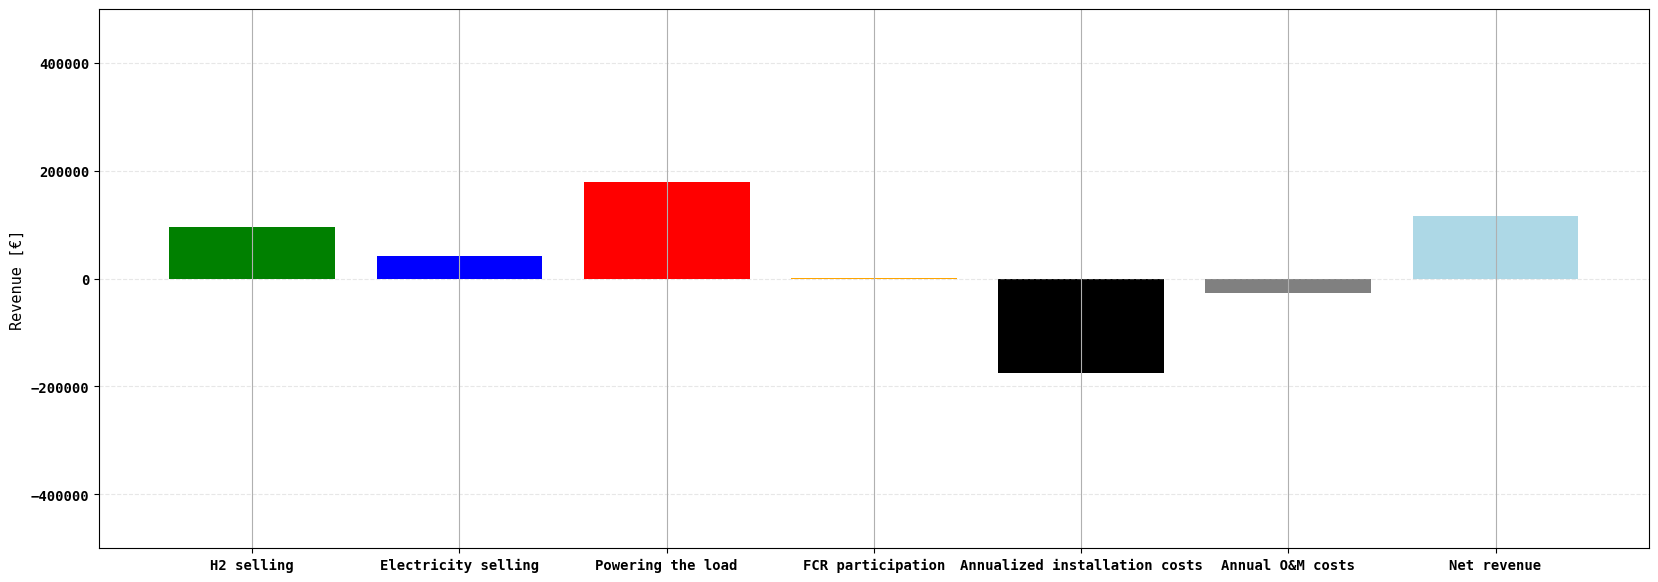

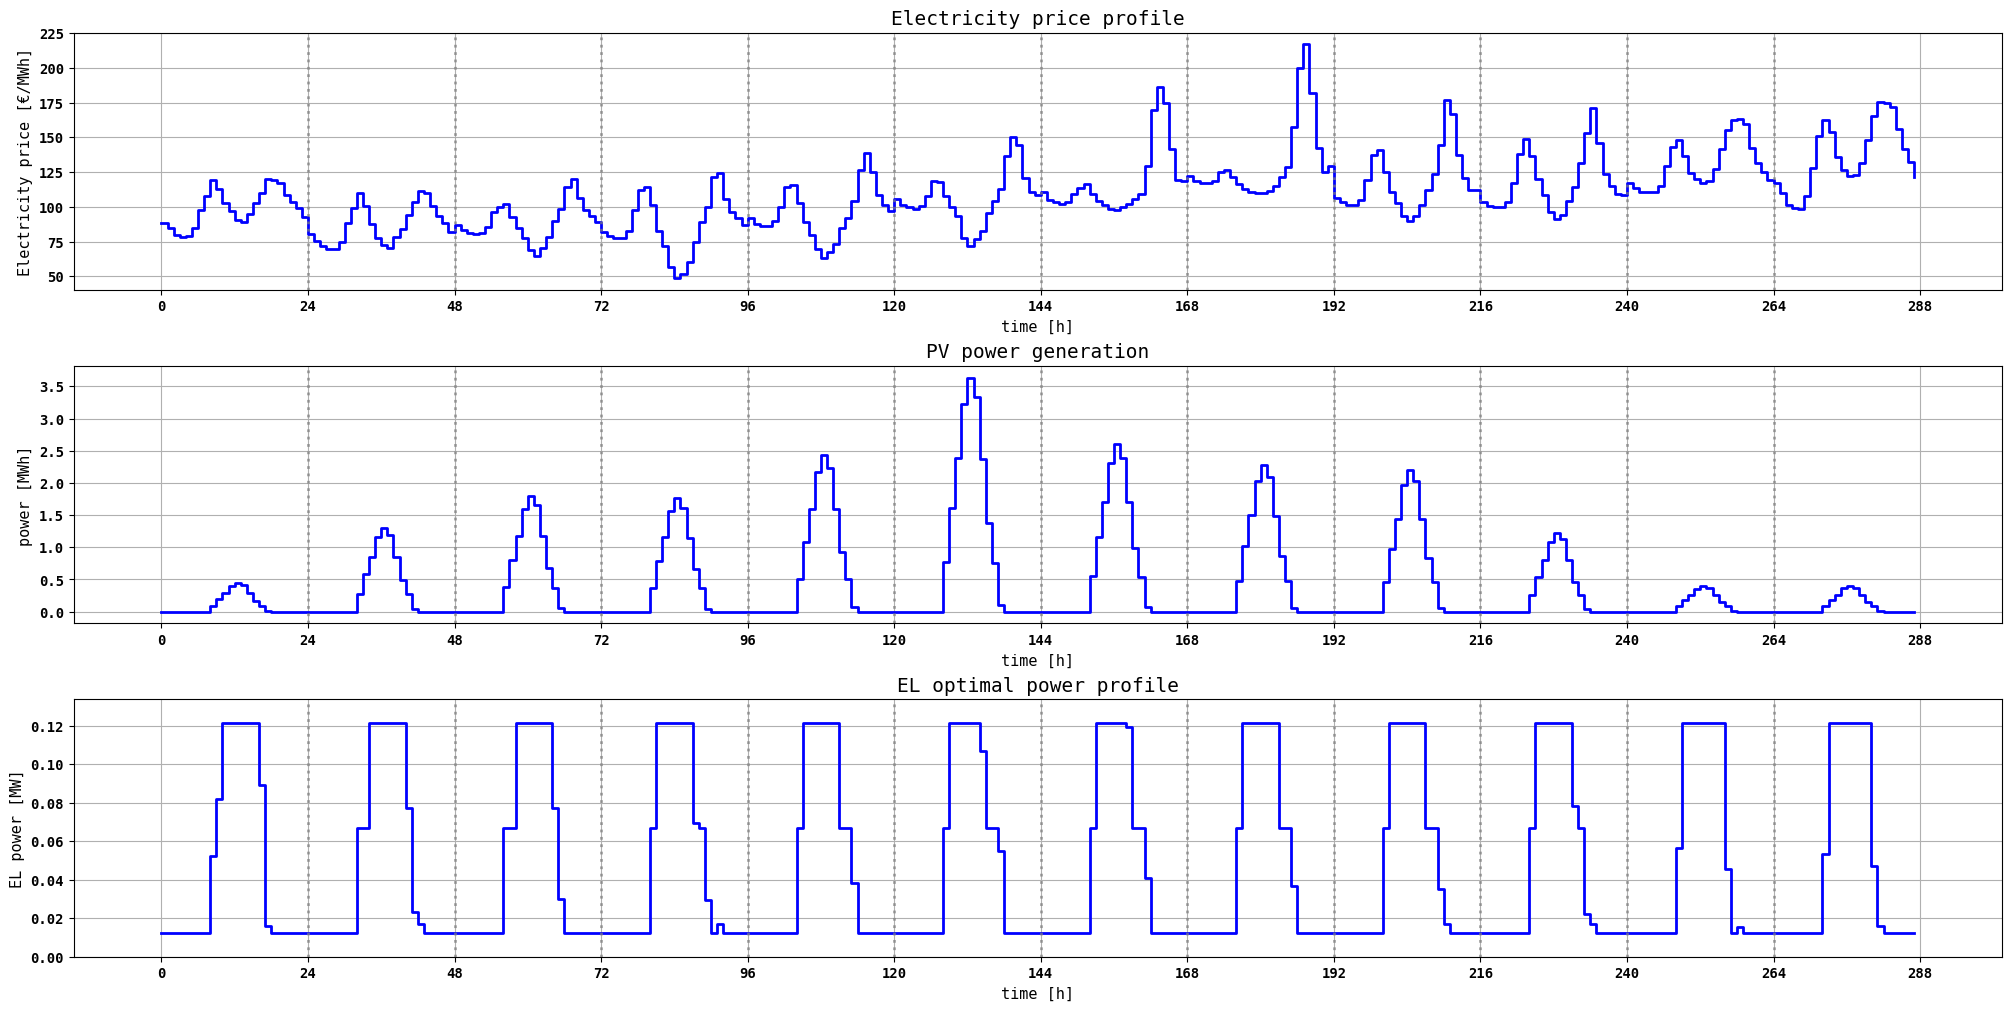

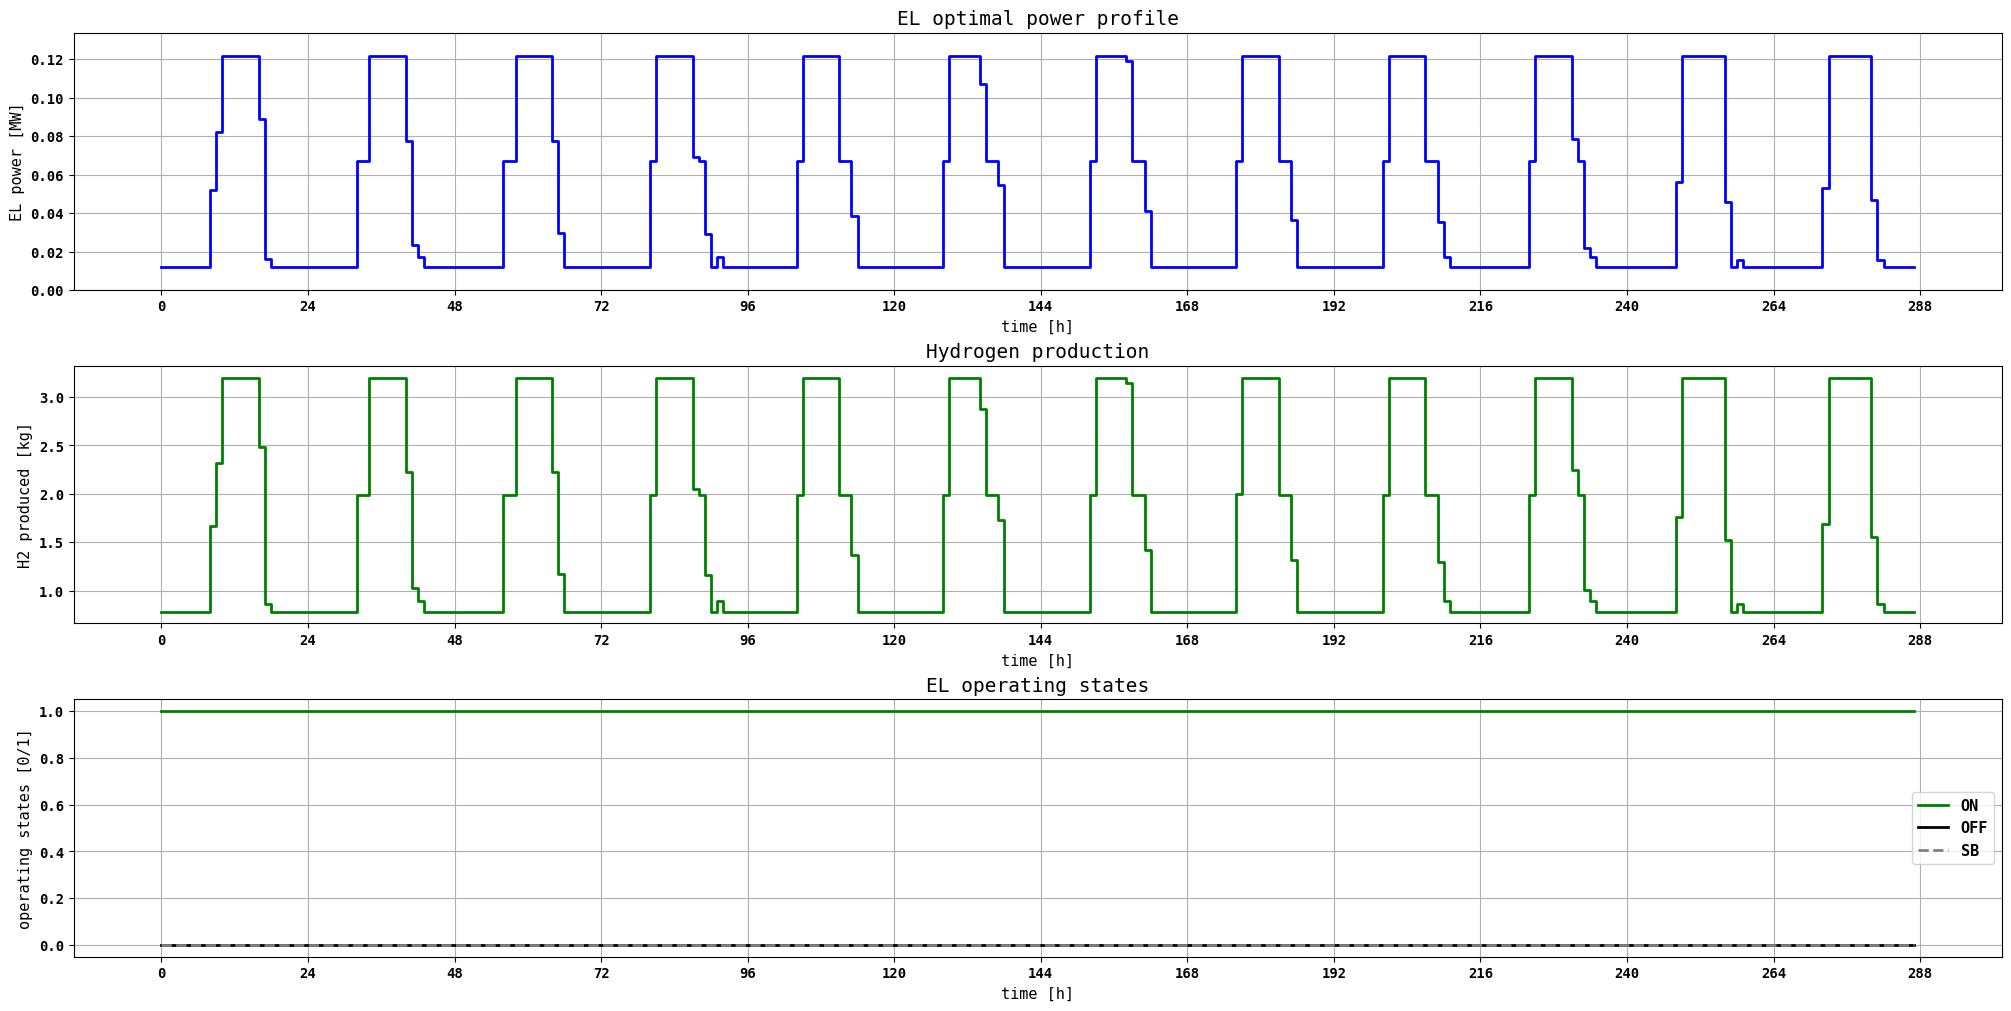

In [68]:
#------------------------------------------------------------------------------------------------
# PLOTTING (1/3)
#------------------------------------------------------------------------------------------------
# time_plot = time[:time_window + 1]      # time array for plotting
time_plot = np.arange(0, N_t + 1)                # time array for single day plotting
time_plot_tdays = np.arange(0, N_t * N_d + 1)    # time array for typical days plotting
day_2plot = 0                                    # specific day for plotting


# Plot settings ---------------------------------------------------------------------------------
plt.rc('figure', figsize=(20, 10))
plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=11, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 2


# RESULTS PLOTS ---------------------------------------------------------------------------------
labels = ['H2 selling', 'Electricity selling', 'Powering the load', 'FCR participation', 'Annualized installation costs', 'Annual O&M costs']
colors = ['green', 'blue', 'red', 'orange', 'black', 'grey']
values = [rev_h2sell, rev_elecsell, rev_loadpower, rev_FCR, -ann_install_costs, -ann_om_costs]

plt.figure(figsize = (20, 7))
plt.bar(labels, values, color = colors)
# plt.bar(['Total Revenue'], [rev_h2sell], label='Hydrogen', color = colors[0])
# plt.bar(['Total Revenue'], [rev_elecsell], bottom=[rev_h2sell], label='Electricity', color = colors[1])
# plt.bar(['Total Revenue'], [rev_FCR], bottom=[rev_h2sell + rev_elecsell], label='Other', color = colors[2])
plt.bar(['Net revenue'], rev_tot, color = 'lightblue')
plt.ylabel("Revenue [€]")
plt.ylim(-5e5, 5e5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
# plt.tight_layout()
# plt.figure(figsize=(6,5))


# INPUT PLOTS -----------------------------------------------------------------------------------
# TIME WINDOW
# Electricity cost plot
figIN, axsIN = plt.subplots(3, 1, layout='constrained')
axsIN[0].step(time_plot_tdays[:-1], C_ele_vals.reshape(-1), color = 'blue', where='post')
axsIN[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN[0].set_xlabel('time [h]')
axsIN[0].set_ylabel('Electricity price [€/MWh]')
axsIN[0].set_title("Electricity price profile")
for day in range(1, N_d):
    x_pos = day * 24
    axsIN[0].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )
# PV power plot
axsIN[1].step(time_plot_tdays[:-1], Ppv_vals.reshape(-1), color = 'blue', where='post')
axsIN[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN[1].set_xlabel('time [h]')
axsIN[1].set_ylabel('power [MWh]')
axsIN[1].set_title("PV power generation")
for day in range(1, N_d):
    x_pos = day * 24
    axsIN[1].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )
# EL power plot
axsIN[2].step(time_plot_tdays[:-1], pel_vals.reshape(-1), color = 'blue', where='post')
axsIN[2].set_xticks([day * 24 for day in range(N_d + 1)])
axsIN[2].set_xlabel('time [h]')
axsIN[2].set_ylabel('EL power [MW]')
axsIN[2].set_title("EL optimal power profile")
axsIN[2].set_ylim(0, 1.1 * Cel_val)
for day in range(1, N_d):
    x_pos = day * 24
    axsIN[2].axvline(
        x=x_pos, 
        color='gray',
        linestyle=':',
        linewidth=2,
        alpha=0.7    # transparency
    )


# EL PLOTS --------------------------------------------------------------------------------------
# TIME WINDOW
# EL power plot
figEL, axsEL = plt.subplots(3, 1, layout='constrained')
axsEL[0].step(time_plot_tdays[:-1], pel_vals.reshape(-1), color = 'blue', where='post')
axsEL[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsEL[0].set_xlabel('time [h]')
axsEL[0].set_ylabel('EL power [MW]')
axsEL[0].set_title("EL optimal power profile")
axsEL[0].set_ylim(0, 1.1 * Cel_val)
# Hydrogen production plot
axsEL[1].step(time_plot_tdays[:-1], hel_vals.reshape(-1), color = 'green', where='post')
axsEL[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsEL[1].set_xlabel('time [h]')
axsEL[1].set_ylabel('H2 produced [kg]')
axsEL[1].set_title("Hydrogen production")
# EL operating states plot
axsEL[2].step(time_plot_tdays[:-1], xel_on_vals.reshape(-1), color = 'green', where='post', label = 'ON')
axsEL[2].step(time_plot_tdays[:-1], xel_off_vals.reshape(-1), color = 'black', where='post', label = 'OFF')
axsEL[2].step(time_plot_tdays[:-1], xel_sb_vals.reshape(-1), color = 'grey', where='post', linestyle='--', label = 'SB')
# axs[2].step(time_plot[day * 24 : (day+1) * 24], xel_su_vals[day * 24 : (day+1) * 24], color = 'red', where='post')
axsEL[2].set_xticks([day * 24 for day in range(N_d + 1)])
axsEL[2].set_xlabel('time [h]')
axsEL[2].set_ylabel('operating states [0/1]')
axsEL[2].set_title("EL operating states")
axsEL[2].legend()

C:\Users\massi\AppData\Local\Temp\ipykernel_22812\2440318603.py:92: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axsFC.set_ylim(0, 1.1 * Cfc_val)


(-0.05, 0.05)

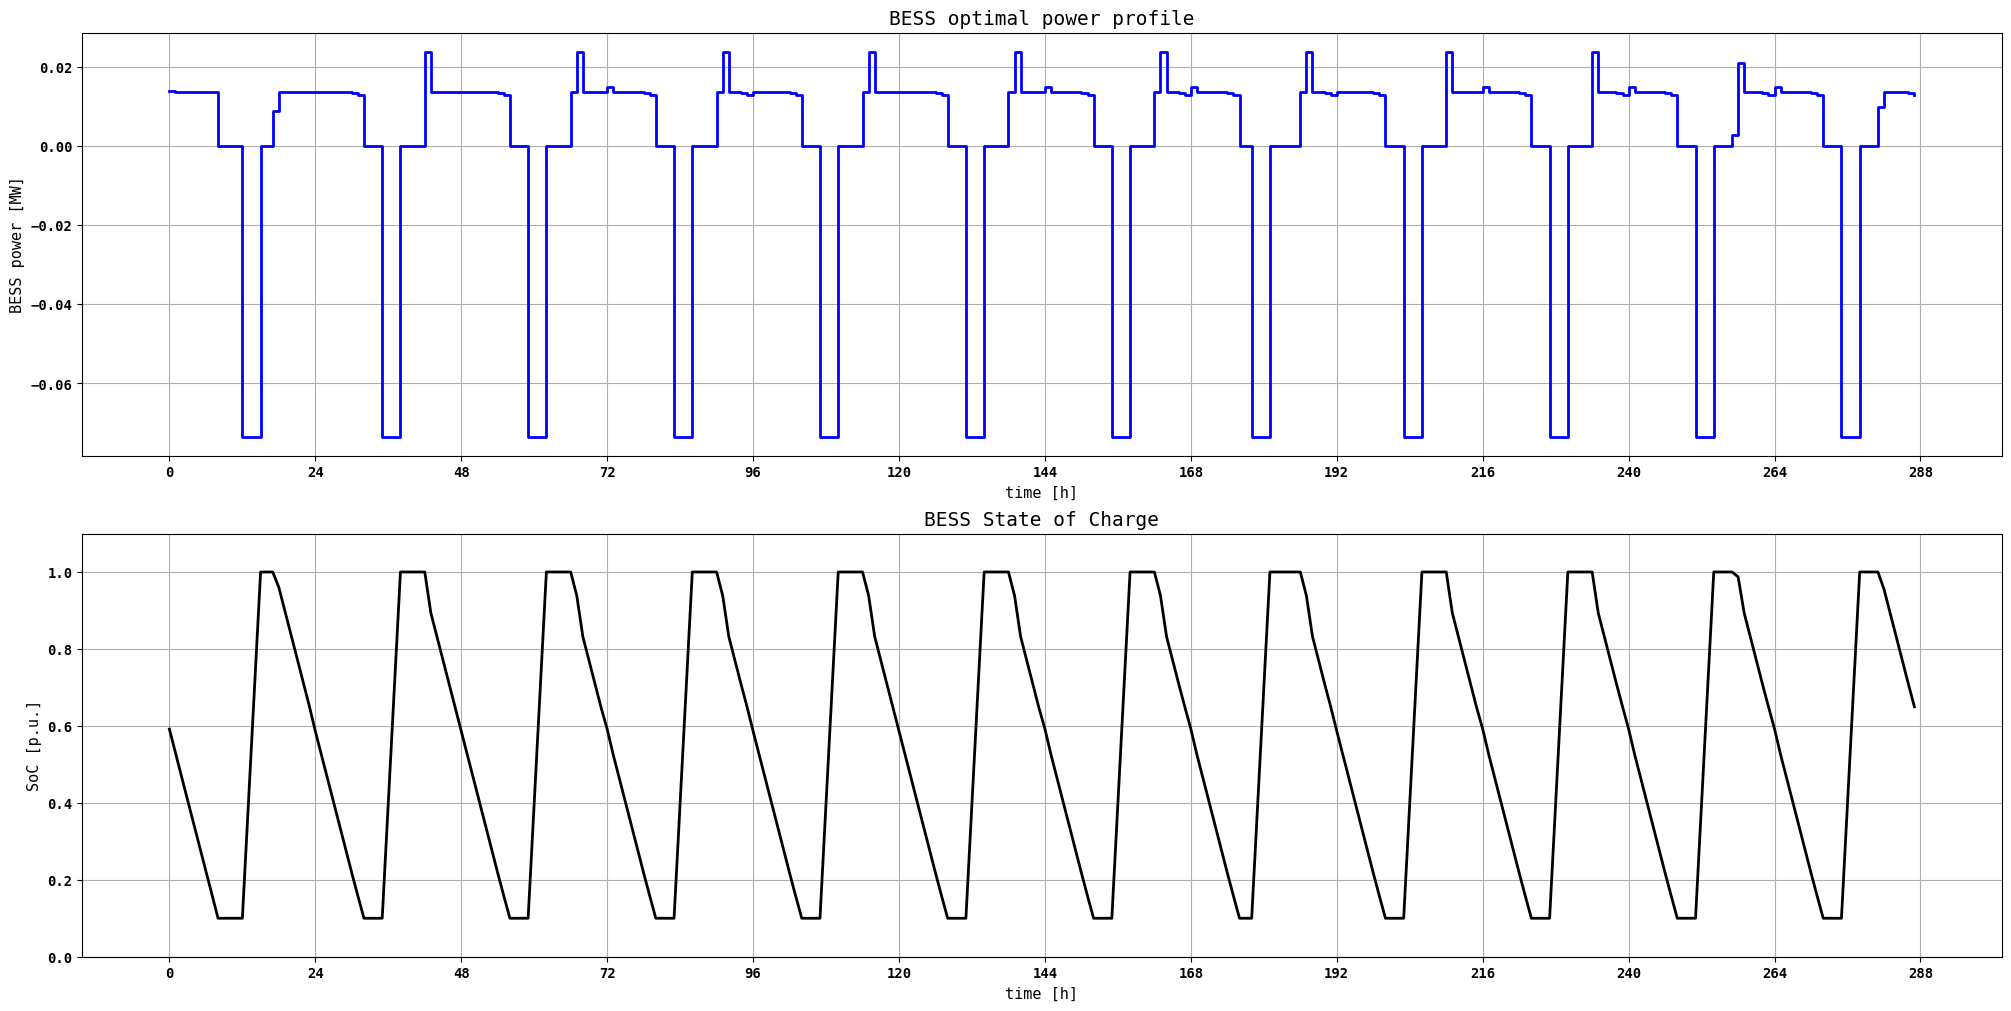

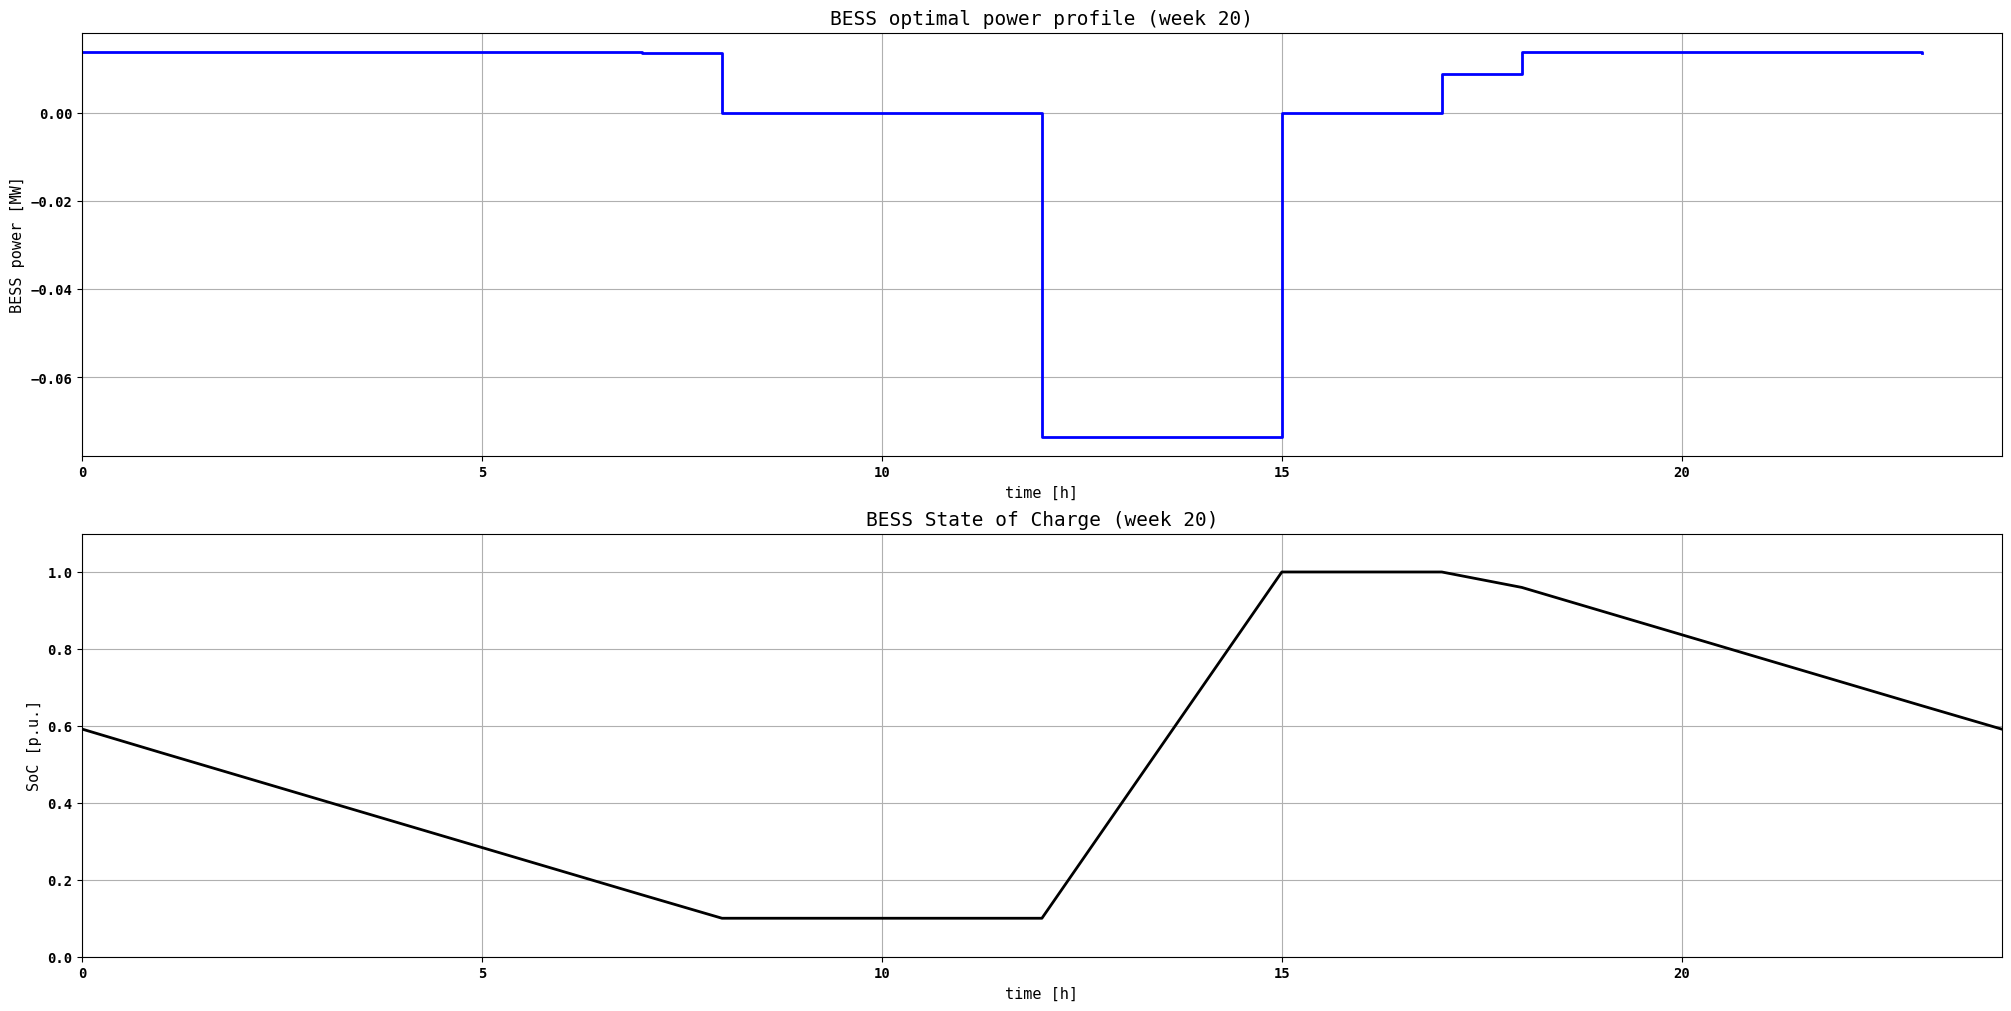

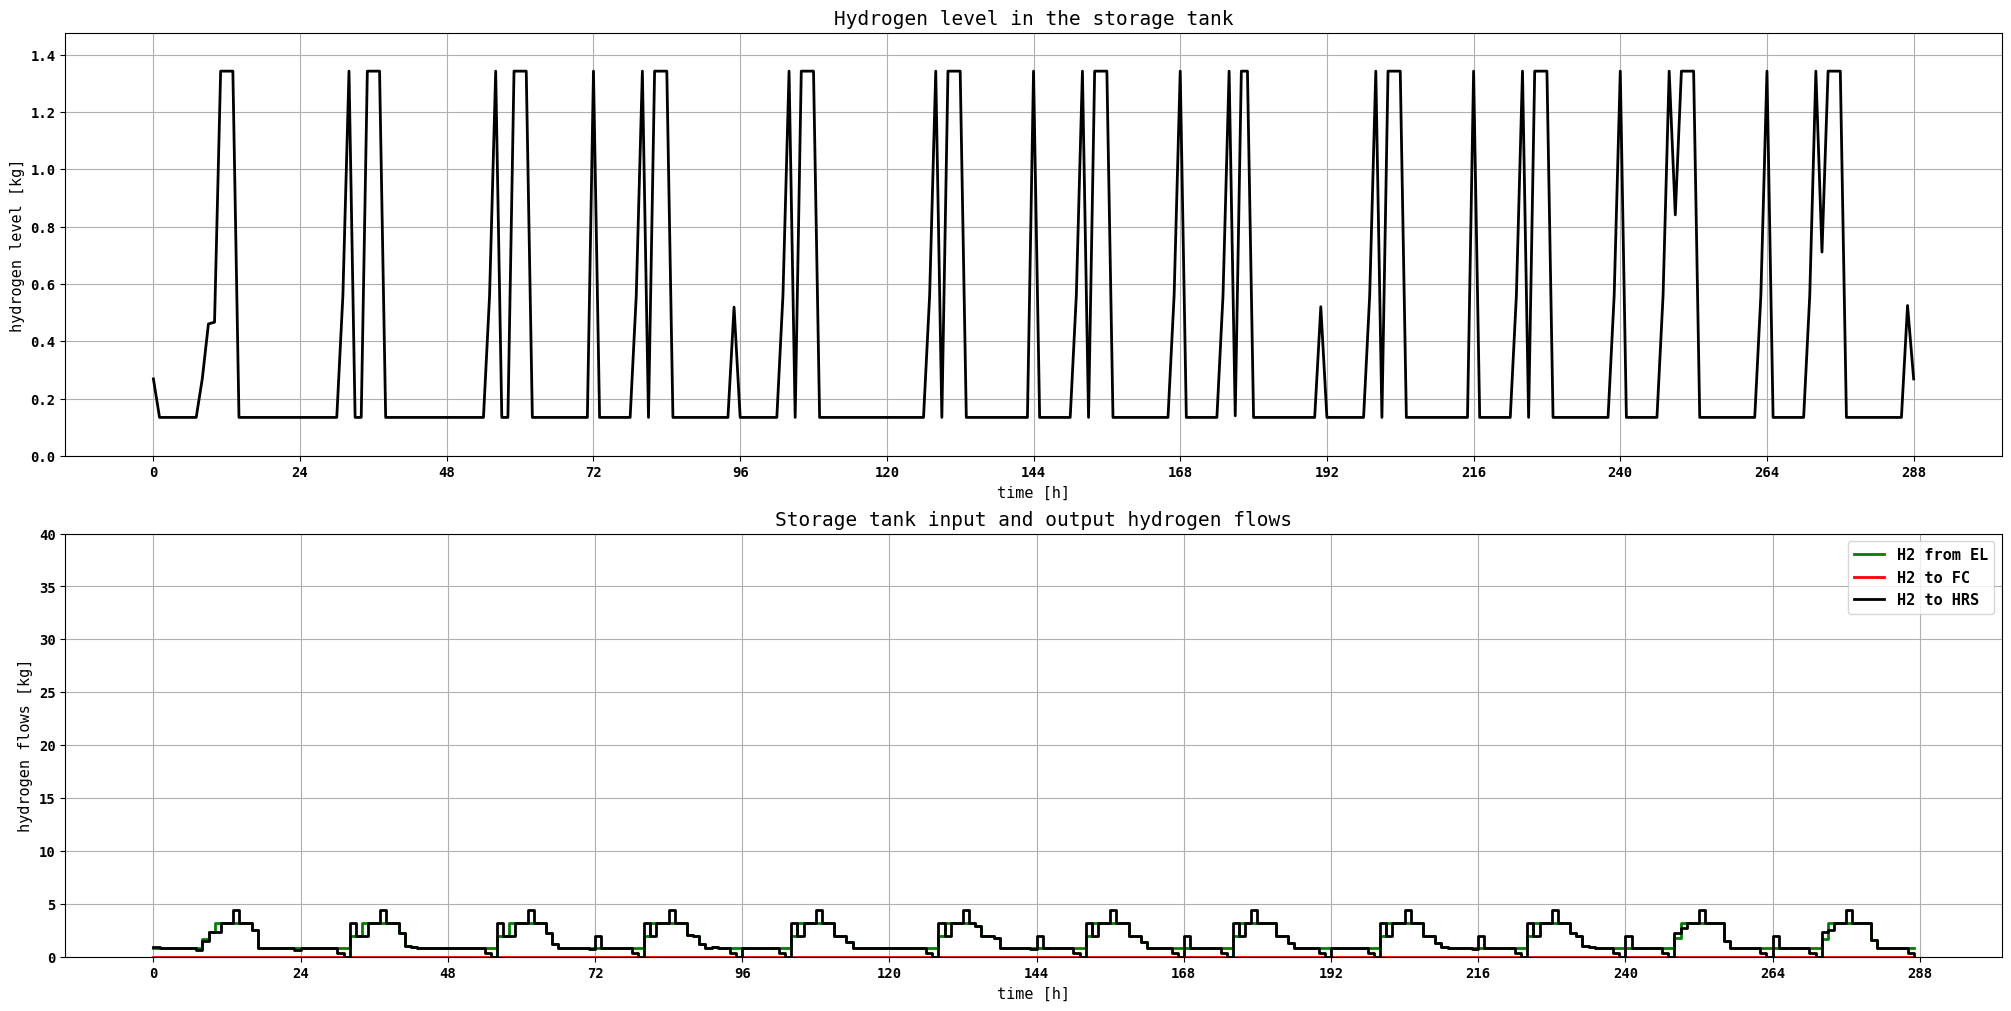

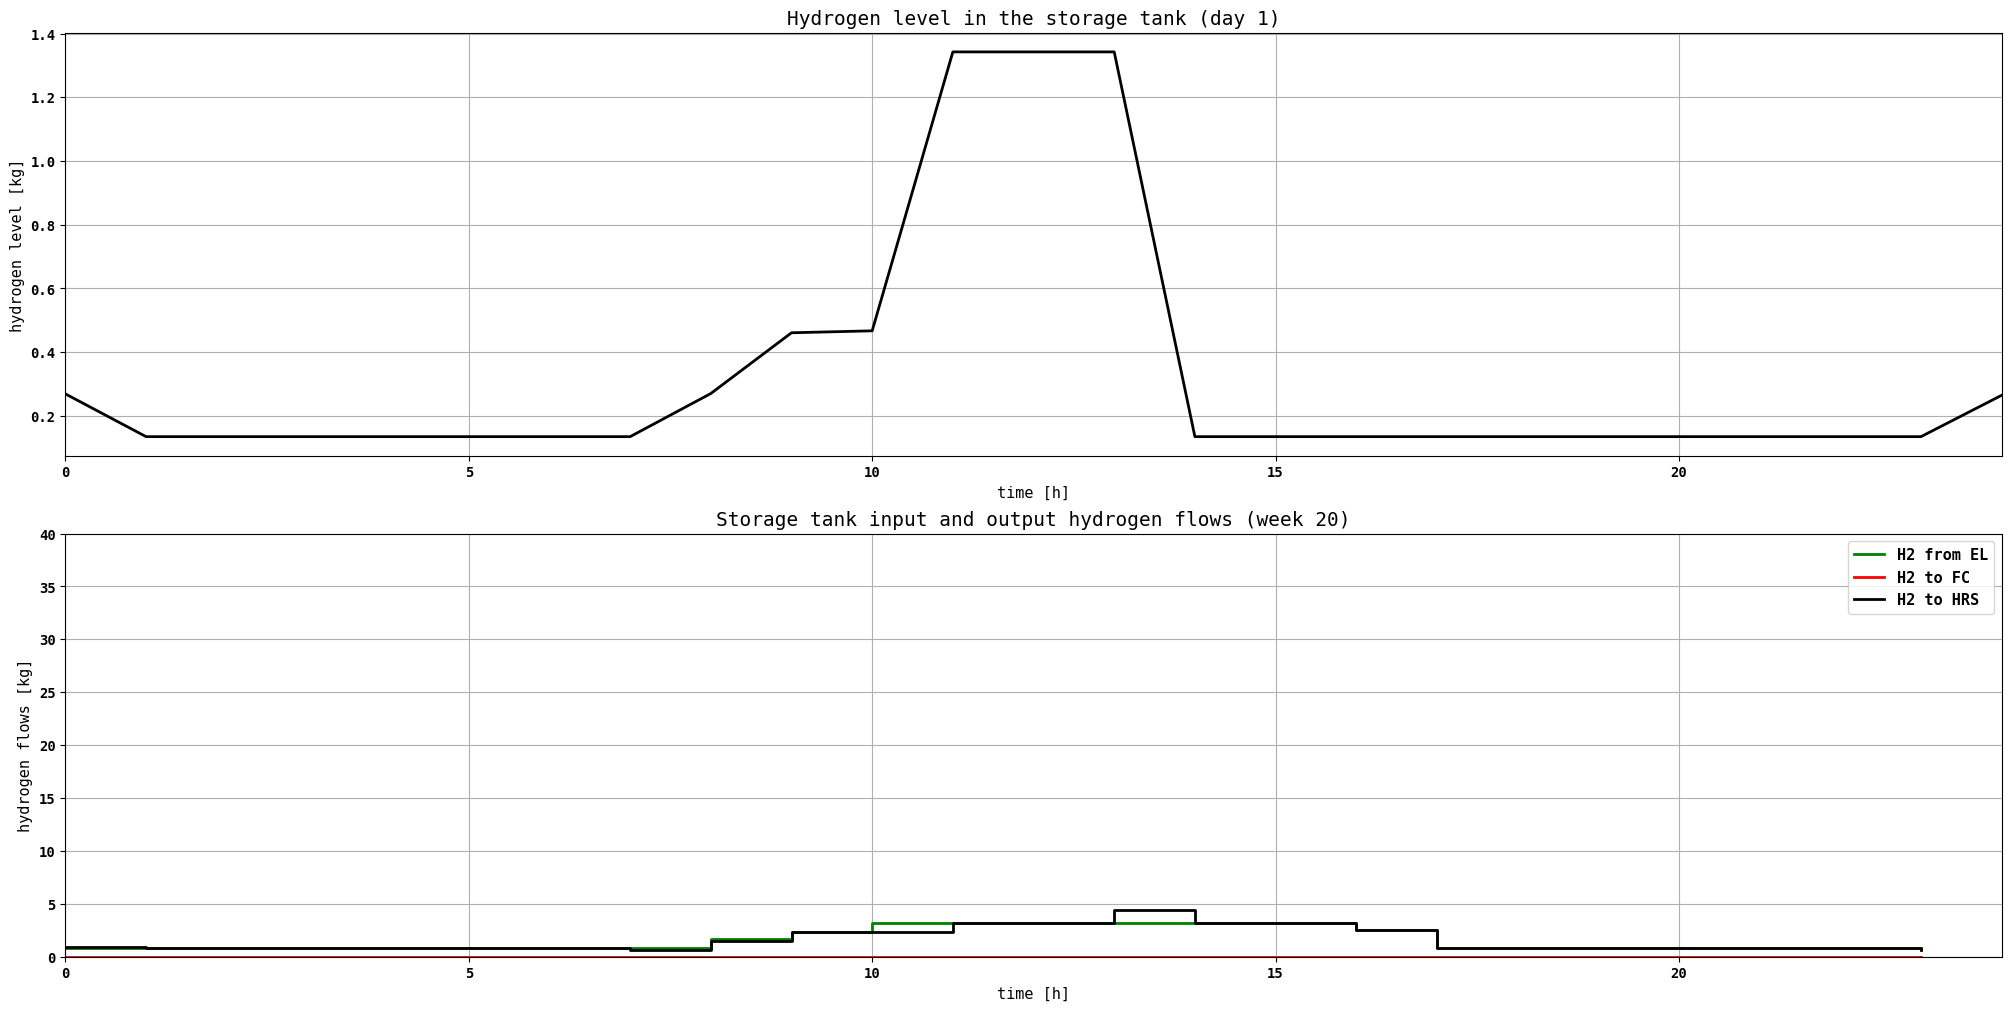

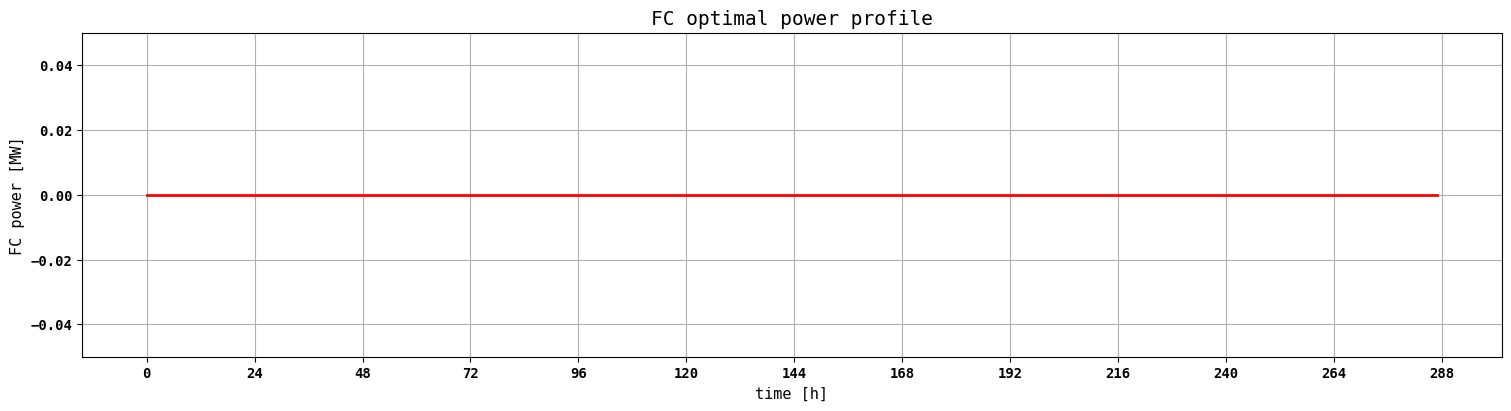

In [69]:
#------------------------------------------------------------------------------------------------
# PLOTTING (2/3)
#------------------------------------------------------------------------------------------------

# BESS PLOTS ------------------------------------------------------------------------------------
# TIME WINDOW
# BESS power plot
figBESS, axsBESS = plt.subplots(2, 1, layout='constrained')
axsBESS[0].step(time_plot_tdays[:-1], pb_vals.reshape(-1), color = 'blue', where='post')
axsBESS[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsBESS[0].set_xlabel('time [h]')
axsBESS[0].set_ylabel('BESS power [MW]')
axsBESS[0].set_title("BESS optimal power profile")
# BESS SoC plot
axsBESS[1].plot(time_plot_tdays[:-1], soc_vals[:, :-1].reshape(-1), color = 'black')
axsBESS[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsBESS[1].set_xlabel('time [h]')
axsBESS[1].set_ylabel('SoC [p.u.]')
axsBESS[1].set_title("BESS State of Charge")
axsBESS[1].set_ylim(0, 1.1)
# # BESS operating states plot
# axs2[2].step(time_plot[week*24*7 : (week+1)*24*7], pb_dch_vals[week*24*7 : (week+1)*24*7] - pb_ch_vals[week*24*7 : (week+1)*24*7], color = 'blue')
# axs2[2].step(time_plot[week*24*7 : (week+1)*24*7], 0.5*xb_vals[week*24*7 : (week+1)*24*7], color = 'black')

# CHOSEN DAY
# BESS power plot
figBESS2, axsBESS2 = plt.subplots(2, 1, layout='constrained')
axsBESS2[0].step(time_plot[:-1], pb_vals[day_2plot, :], color = 'blue', where='post')
axsBESS2[0].set_xlabel('time [h]')
axsBESS2[0].set_ylabel('BESS power [MW]')
axsBESS2[0].set_title("BESS optimal power profile (week 20)")
axsBESS2[0].set_xlim(0, 24)
# BESS SoC plot
axsBESS2[1].plot(time_plot, soc_vals[day_2plot, :], color = 'black')  # SoC values are shifted forwards by 1 to match power plots
axsBESS2[1].set_xlabel('time [h]')
axsBESS2[1].set_ylabel('SoC [p.u.]')
axsBESS2[1].set_title("BESS State of Charge (week 20)")
axsBESS2[1].set_ylim(0, 1.1)
axsBESS2[1].set_xlim(0, 24)


# HYDROGEN STORAGE PLOTS ------------------------------------------------------------------------
# TIME WINDOW
# HSS hydrogen level plot
figHSS, axsHSS = plt.subplots(2, 1, layout='constrained')
# axsHSS[0].plot(time_plot_tdays[:-1], hhss_vals[:, :-1].reshape(-1), color = 'black')
axsHSS[0].plot(time_plot_tdays, np.append(hhss_vals[:, :-1].reshape(-1), hhss_seas_vals[-1]), color = 'black')
axsHSS[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsHSS[0].set_xlabel('time [h]')
axsHSS[0].set_ylabel('hydrogen level [kg]')
axsHSS[0].set_title("Hydrogen level in the storage tank")
axsHSS[0].set_ylim(0, 1.1 * Chss_val)
# Input and outputs of the HSS (without efficiencies)
axsHSS[1].step(time_plot_tdays[:-1], hel_vals.reshape(-1), color = 'green', label = 'H2 from EL', where='post')
axsHSS[1].step(time_plot_tdays[:-1], hfc_vals.reshape(-1), color = 'red', label = 'H2 to FC', where='post')
axsHSS[1].step(time_plot_tdays[:-1], hdem_vals.reshape(-1), color = 'black', label = 'H2 to HRS', where='post')
axsHSS[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsHSS[1].set_xlabel('time [h]')
axsHSS[1].set_ylabel('hydrogen flows [kg]')
axsHSS[1].set_title("Storage tank input and output hydrogen flows")
axsHSS[1].set_ylim(0, 40)
axsHSS[1].legend()

# CHOSEN DAY
# HSS hydrogen level plot
figHSS2, axsHSS2 = plt.subplots(2, 1, layout='constrained')
axsHSS2[0].plot(time_plot, hhss_vals[day_2plot, :], color = 'black')
axsHSS2[0].set_xlabel('time [h]')
axsHSS2[0].set_ylabel('hydrogen level [kg]')
axsHSS2[0].set_title(f"Hydrogen level in the storage tank (day {day_2plot + 1})")
# axsHSS2[0].set_ylim(0.95 * min(hhss_vals[week*24*7 + 1 : (week+1)*24*7 + 1]), 1.05 * max(hhss_vals[week*24*7 + 1 : (week+1)*24*7 + 1]))
axsHSS2[0].set_xlim(0, 24)
# Input and outputs of the HSS (without efficiencies)
axsHSS2[1].step(time_plot[:-1], hel_vals[day_2plot, :], color = 'green', label = 'H2 from EL', where='post')
axsHSS2[1].step(time_plot[:-1], hfc_vals[day_2plot, :], color = 'red', label = 'H2 to FC', where='post')
axsHSS2[1].step(time_plot[:-1], hdem_vals[day_2plot, :], color = 'black', label = 'H2 to HRS', where='post')
axsHSS2[1].set_xlabel('time [h]')
axsHSS2[1].set_ylabel('hydrogen flows [kg]')
axsHSS2[1].set_title("Storage tank input and output hydrogen flows (week 20)")
axsHSS2[1].set_ylim(0, 40)
axsHSS2[1].set_xlim(0, 24)
axsHSS2[1].legend()


# FC power plot
figFC, axsFC = plt.subplots(layout='constrained', figsize=(15, 4))
axsFC.step(time_plot_tdays[:-1], pfc_vals.reshape(-1), color = 'red', where='post')
axsFC.set_xticks([day * 24 for day in range(N_d + 1)])
axsFC.set_xlabel('time [h]')
axsFC.set_ylabel('FC power [MW]')
axsFC.set_title("FC optimal power profile")
axsFC.set_ylim(0, 1.1 * Cfc_val)

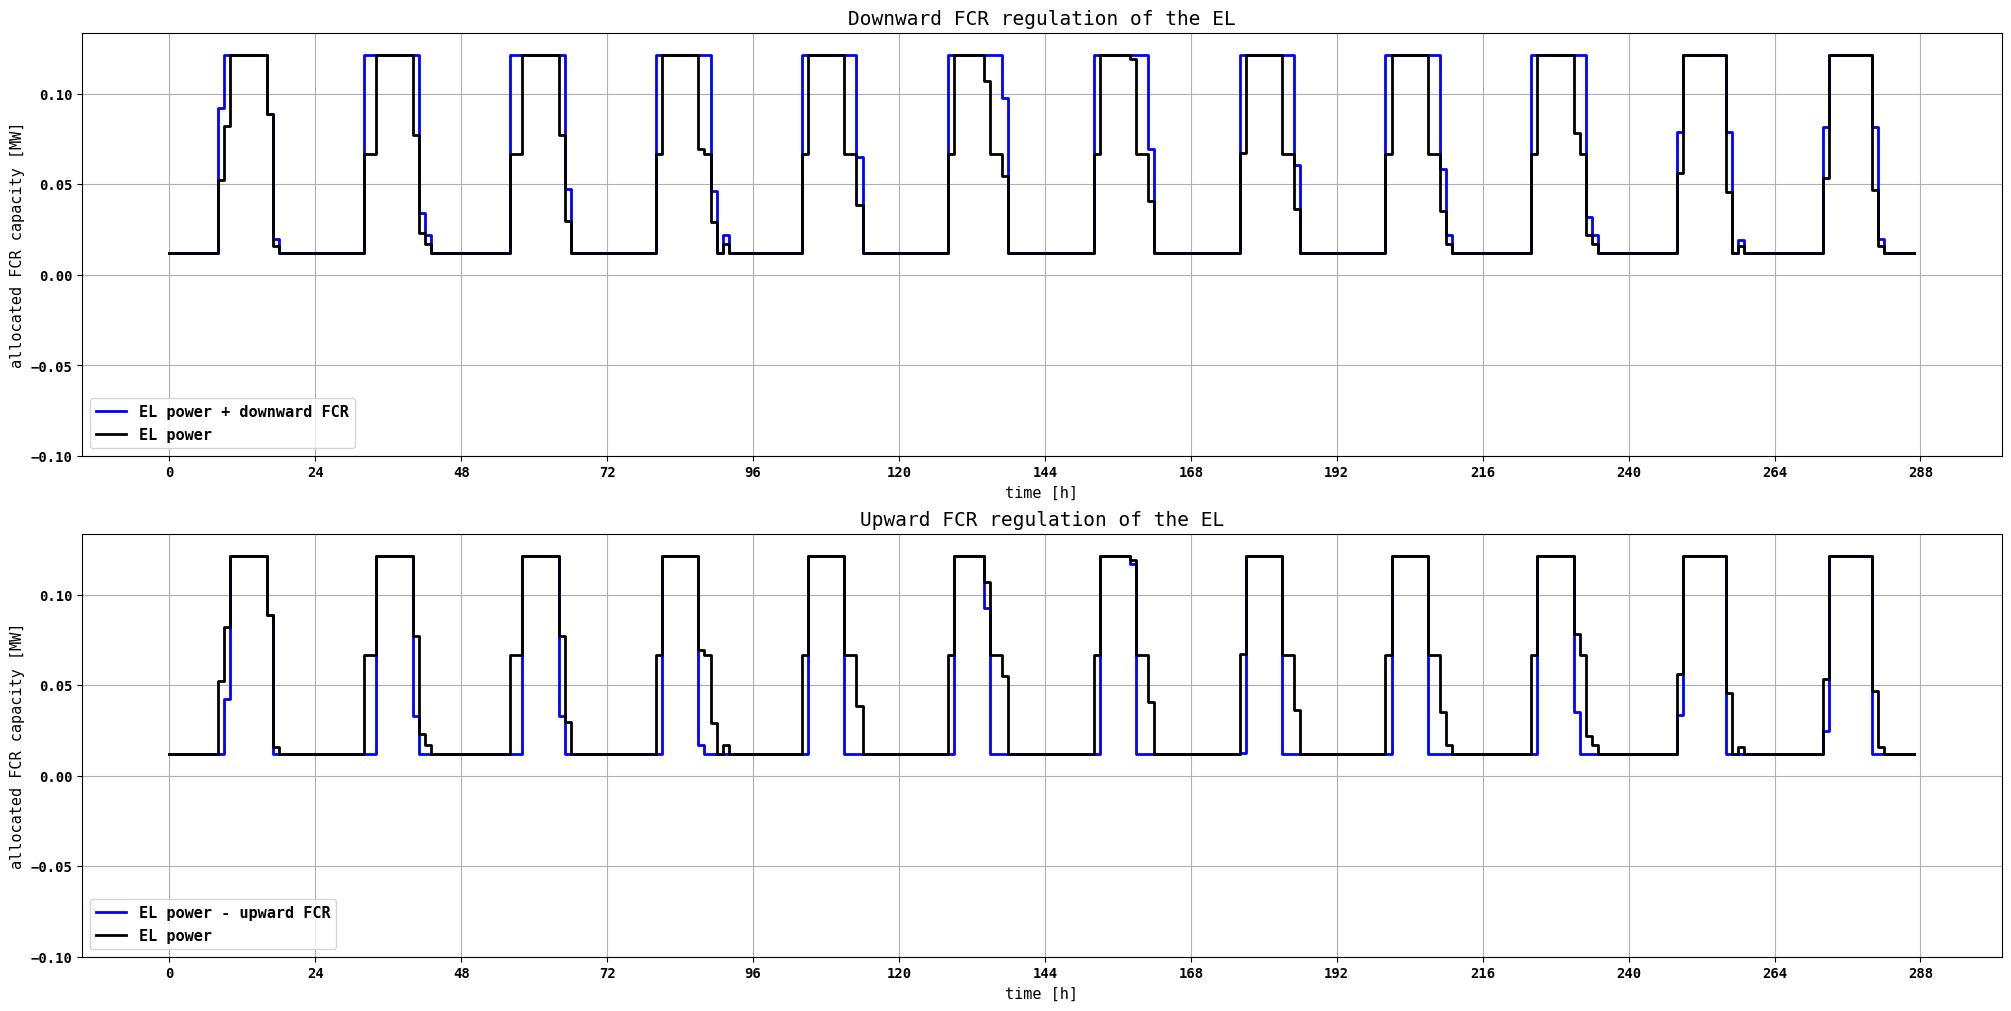

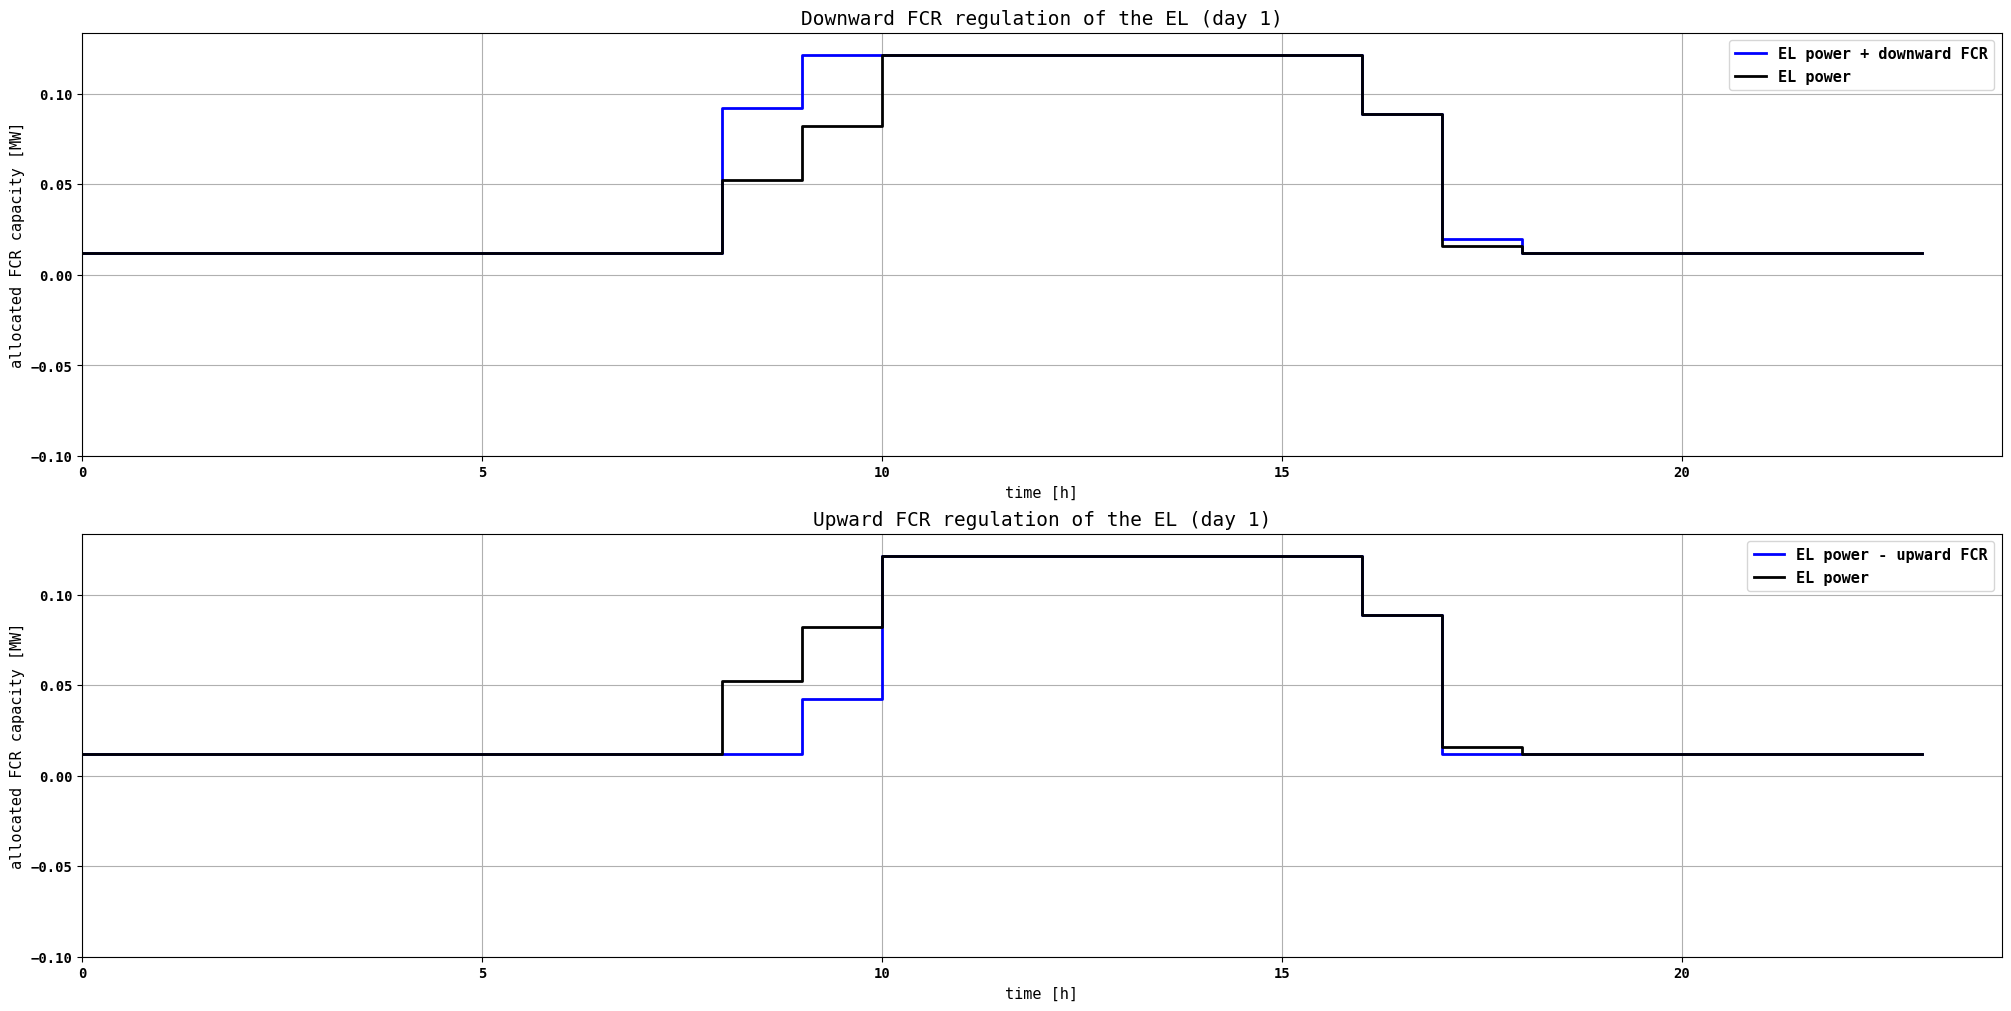

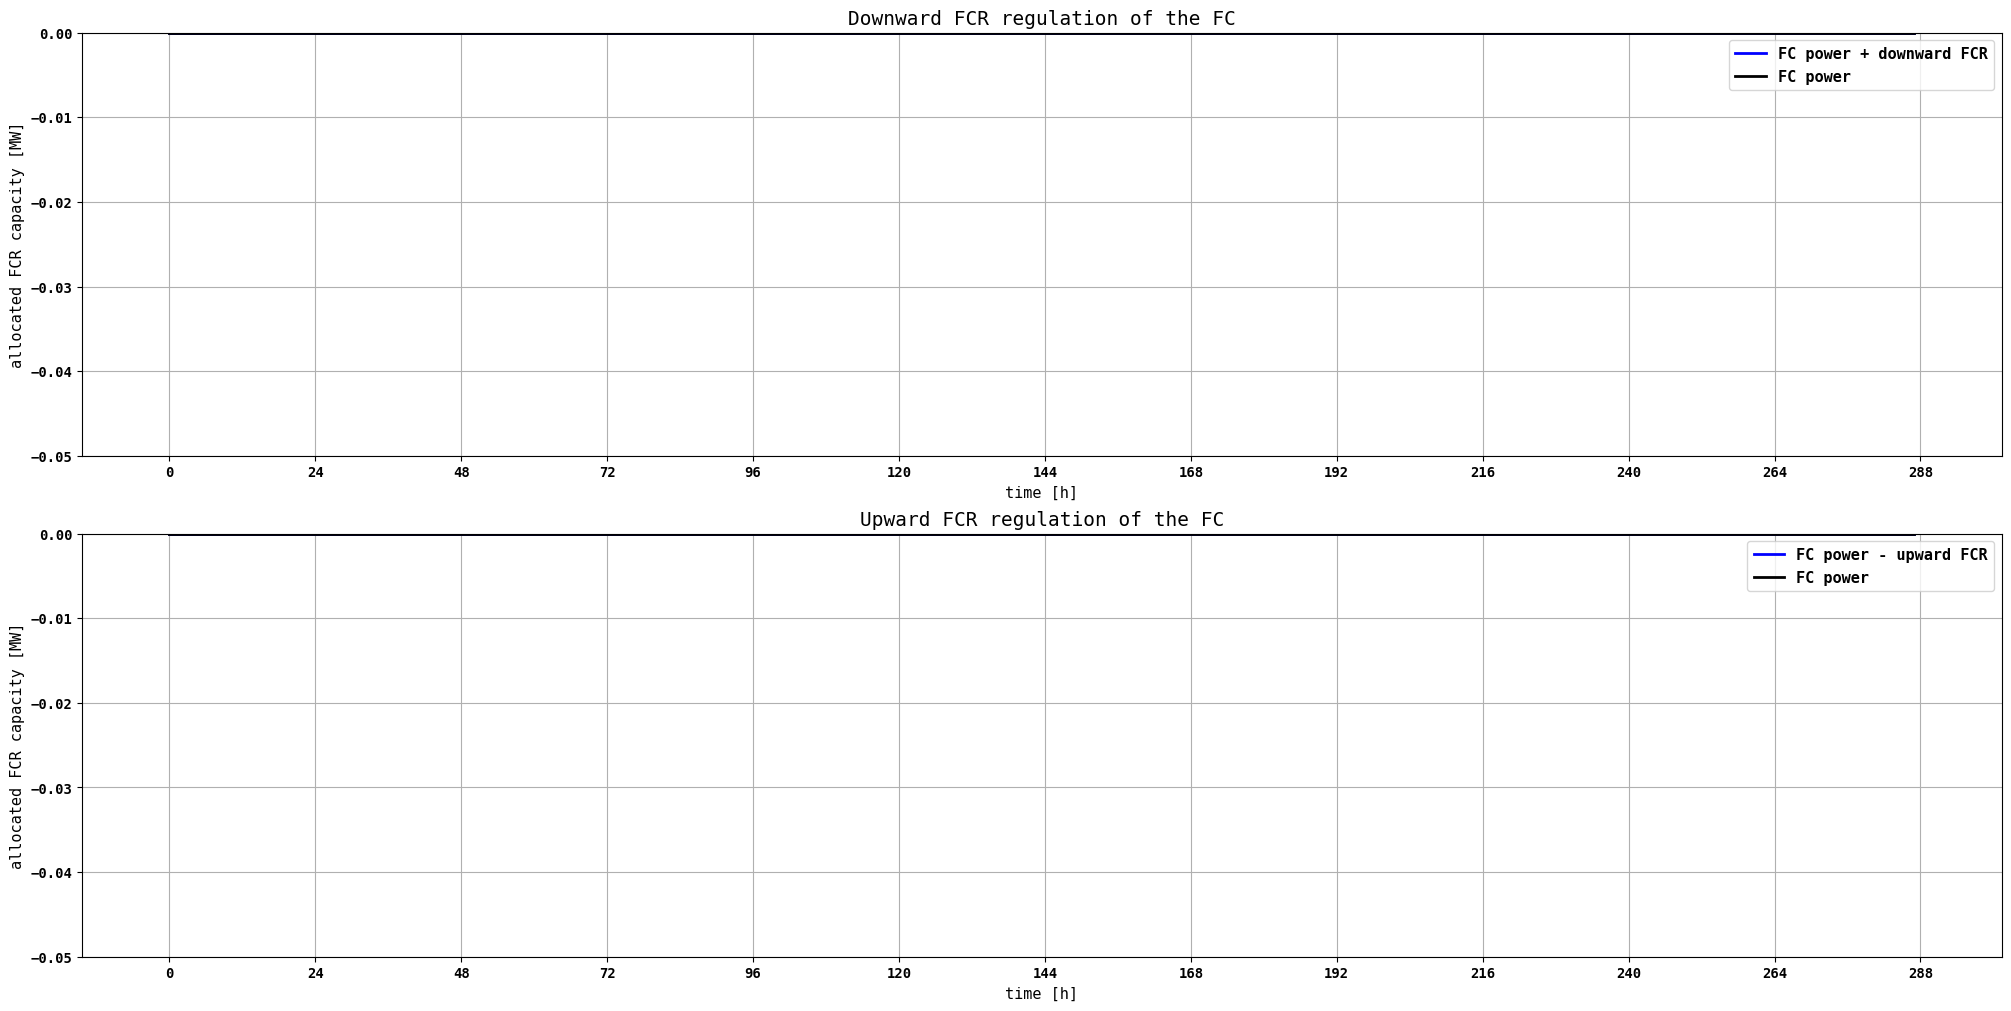

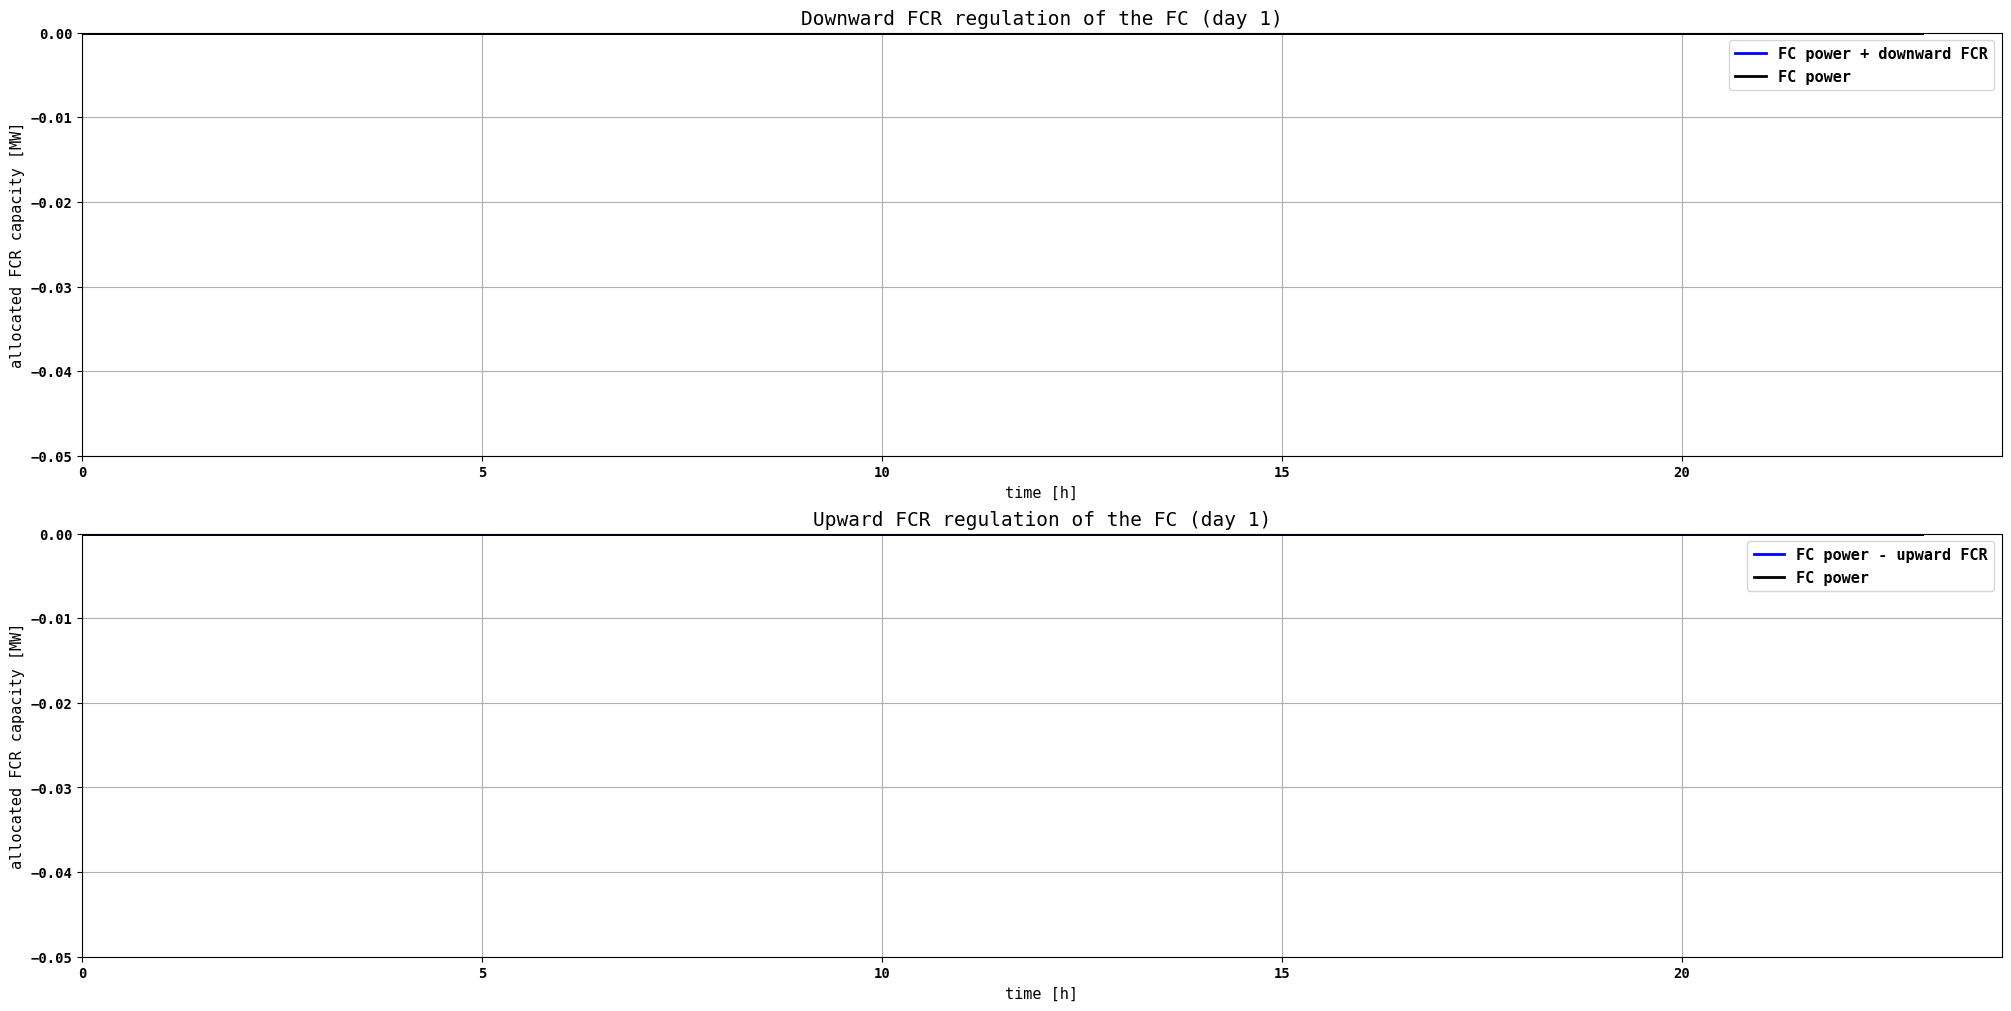

In [70]:
#------------------------------------------------------------------------------------------------
# PLOTTING (3/3)
#------------------------------------------------------------------------------------------------

# FCR EL PLOTS ----------------------------------------------------------------------------------
# TIME WINDOW
# FCR EL capacity allocation plot, downward regulation
figFCRel, axsFCRel = plt.subplots(2, 1, layout = 'constrained')
axsFCRel[0].step(time_plot_tdays[:-1], pel_vals.reshape(-1) + pel_fcr_dwn_vals.reshape(-1), color = 'blue', label = 'EL power + downward FCR', where='post')
axsFCRel[0].step(time_plot_tdays[:-1], pel_vals.reshape(-1), color = 'black', label = 'EL power', where='post')
axsFCRel[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRel[0].set_xlabel('time [h]')
axsFCRel[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[0].set_title("Downward FCR regulation of the EL")
axsFCRel[0].set_ylim(-0.1, 1.1 * Cel_val)
axsFCRel[0].legend()
# FCR EL capacity allocation plot, upward regulation
axsFCRel[1].step(time_plot_tdays[:-1], pel_vals.reshape(-1) - pel_fcr_up_vals.reshape(-1), color = 'blue', label = 'EL power - upward FCR', where='post')
axsFCRel[1].step(time_plot_tdays[:-1], pel_vals.reshape(-1), color = 'black', label = 'EL power', where='post')
axsFCRel[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRel[1].set_xlabel('time [h]')
axsFCRel[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[1].set_title("Upward FCR regulation of the EL")
axsFCRel[1].set_ylim(-0.1, 1.1 * Cel_val)
axsFCRel[1].legend()

# CHOSEN DAY
# FCR EL capacity allocation plot, downward regulation
figFCRel, axsFCRel = plt.subplots(2, 1, layout = 'constrained')
axsFCRel[0].step(time_plot[:-1], pel_vals[day_2plot, :] + pel_fcr_dwn_vals[day_2plot, :], color = 'blue', label = 'EL power + downward FCR', where='post')
axsFCRel[0].step(time_plot[:-1], pel_vals[day_2plot, :], color = 'black', label = 'EL power', where='post')
axsFCRel[0].set_xlabel('time [h]')
axsFCRel[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[0].set_title(f"Downward FCR regulation of the EL (day {day_2plot + 1})")
axsFCRel[0].set_ylim(-0.1, 1.1 * Cel_val)
axsFCRel[0].set_xlim(0, 24)
axsFCRel[0].legend()
# FCR EL capacity allocation plot, upward regulation
axsFCRel[1].step(time_plot[:-1], pel_vals[day_2plot, :] - pel_fcr_up_vals[day_2plot, :], color = 'blue', label = 'EL power - upward FCR', where='post')
axsFCRel[1].step(time_plot[:-1], pel_vals[day_2plot, :], color = 'black', label = 'EL power', where='post')
axsFCRel[1].set_xlabel('time [h]')
axsFCRel[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRel[1].set_title(f"Upward FCR regulation of the EL (day {day_2plot + 1})")
axsFCRel[1].set_ylim(-0.1, 1.1 * Cel_val)
axsFCRel[1].set_xlim(0, 24)
axsFCRel[1].legend()


# FCR FC PLOTS ----------------------------------------------------------------------------------
# TIME WINDOW
# FCR FC capacity allocation plot, downward regulation
figFCRfc, axsFCRfc = plt.subplots(2, 1, layout = 'constrained')
axsFCRfc[0].step(time_plot_tdays[:-1], pfc_vals.reshape(-1) + pfc_fcr_up_vals.reshape(-1), color = 'blue', label = 'FC power + downward FCR', where='post')
axsFCRfc[0].step(time_plot_tdays[:-1], pfc_vals.reshape(-1), color = 'black', label = 'FC power', where='post')
axsFCRfc[0].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRfc[0].set_xlabel('time [h]')
axsFCRfc[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[0].set_title("Downward FCR regulation of the FC")
axsFCRfc[0].set_ylim(-0.05, 1.1 * Cfc_val)
axsFCRfc[0].legend()
# FCR FC capacity allocation plot, upward regulation
axsFCRfc[1].step(time_plot_tdays[:-1], pfc_vals.reshape(-1) - pfc_fcr_dwn_vals.reshape(-1), color = 'blue', label = 'FC power - upward FCR', where='post')
axsFCRfc[1].step(time_plot_tdays[:-1], pfc_vals.reshape(-1), color = 'black', label = 'FC power', where='post')
axsFCRfc[1].set_xticks([day * 24 for day in range(N_d + 1)])
axsFCRfc[1].set_xlabel('time [h]')
axsFCRfc[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[1].set_title("Upward FCR regulation of the FC")
axsFCRfc[1].set_ylim(-0.05, 1.1 * Cfc_val)
axsFCRfc[1].legend()

# CHOSEN DAY
# FCR FC capacity allocation plot, downward regulation
figFCRfc, axsFCRfc = plt.subplots(2, 1, layout = 'constrained')
axsFCRfc[0].step(time_plot[:-1], pfc_vals[day_2plot, :] + pfc_fcr_up_vals[day_2plot, :], color = 'blue', label = 'FC power + downward FCR', where='post')
axsFCRfc[0].step(time_plot[:-1], pfc_vals[day_2plot, :], color = 'black', label = 'FC power', where='post')
axsFCRfc[0].set_xlabel('time [h]')
axsFCRfc[0].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[0].set_title(f"Downward FCR regulation of the FC (day {day_2plot + 1})")
axsFCRfc[0].set_ylim(-0.05, 1.1 * Cfc_val)
axsFCRfc[0].set_xlim(0, 24)
axsFCRfc[0].legend()
# FCR EL capacity allocation plot, upward regulation
axsFCRfc[1].step(time_plot[:-1], pfc_vals[day_2plot, :] - pfc_fcr_dwn_vals[day_2plot, :], color = 'blue', label = 'FC power - upward FCR', where='post')
axsFCRfc[1].step(time_plot[:-1], pfc_vals[day_2plot, :], color = 'black', label = 'FC power', where='post')
axsFCRfc[1].set_xlabel('time [h]')
axsFCRfc[1].set_ylabel('allocated FCR capacity [MW]')
axsFCRfc[1].set_title(f"Upward FCR regulation of the FC (day {day_2plot + 1})")
axsFCRfc[1].set_ylim(-0.05, 1.1 * Cfc_val)
axsFCRfc[1].set_xlim(0, 24)
axsFCRfc[1].legend()

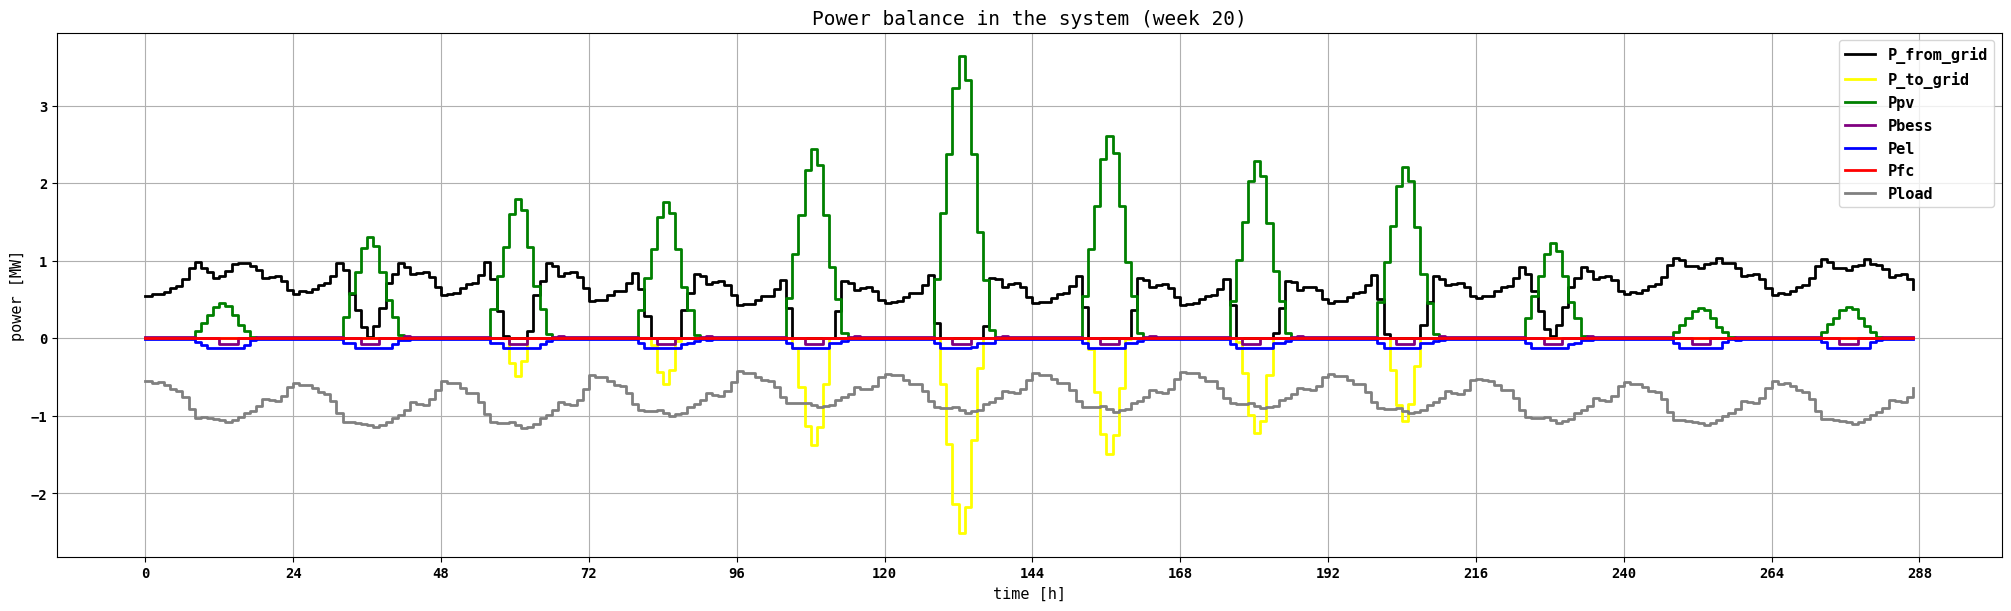

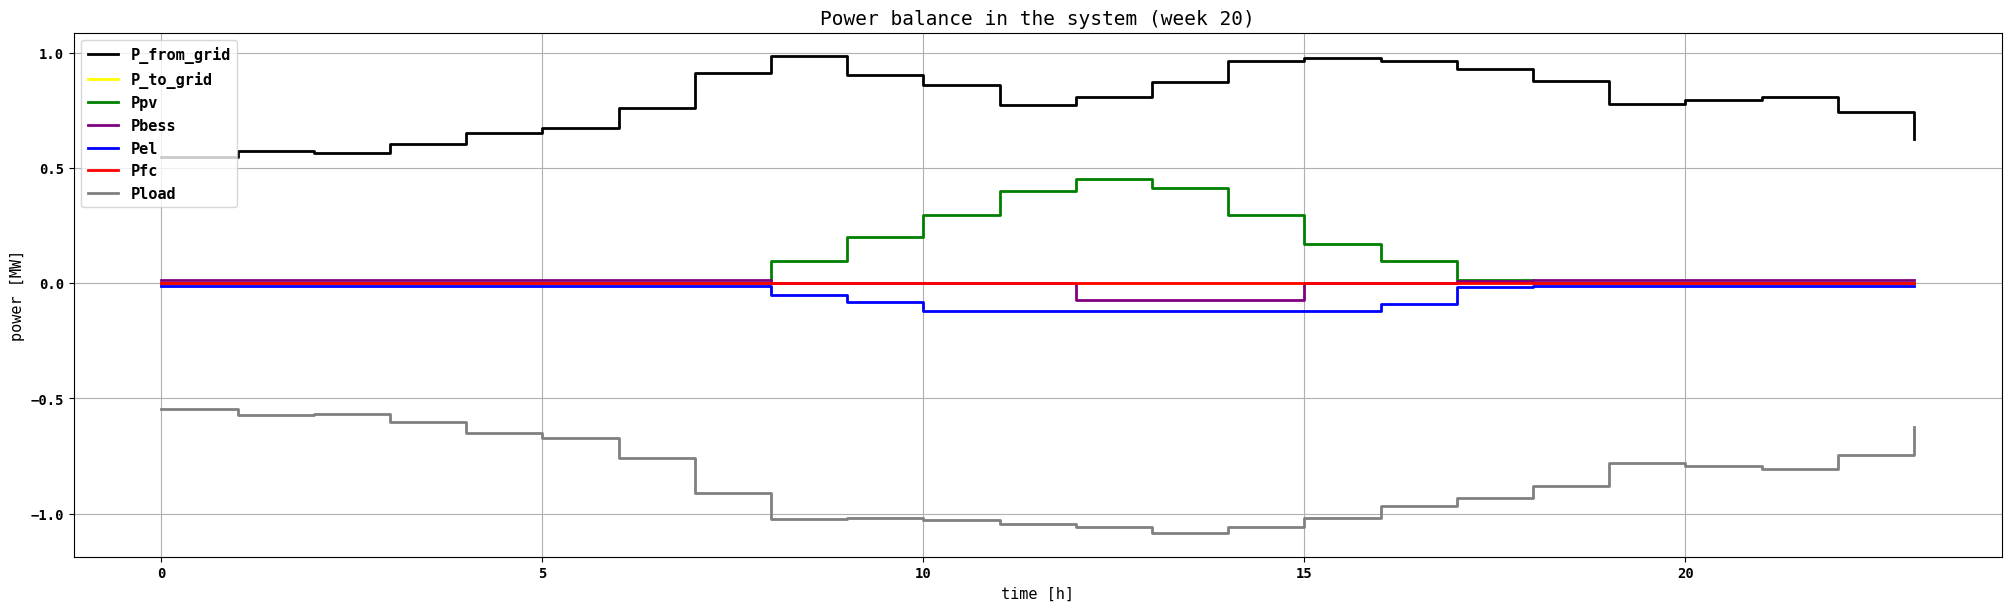

In [71]:
#------------------------------------------------------------------------------------------------
# PLOTTING (4/4)
#------------------------------------------------------------------------------------------------

# POWER BALANCE PLOTS --------------------------------------------------------------------------------------
# TIME WINDOW
# Power balance plot
figPow, axsPow = plt.subplots(layout='constrained', figsize = (20, 6))
axsPow.step(time_plot_tdays[:-1], pgrid_p_vals.reshape(-1), color = 'black', label = 'P_from_grid', where='post')
axsPow.step(time_plot_tdays[:-1], -pgrid_n_vals.reshape(-1), color = 'yellow', label = 'P_to_grid', where='post')
axsPow.step(time_plot_tdays[:-1], Ppv_vals.reshape(-1), color = 'green', label = 'Ppv', where='post')
axsPow.step(time_plot_tdays[:-1], pb_vals.reshape(-1), color = 'purple', label = 'Pbess', where='post')
axsPow.step(time_plot_tdays[:-1], -pel_vals.reshape(-1), color = 'blue', label = 'Pel', where='post')
axsPow.step(time_plot_tdays[:-1], pfc_vals.reshape(-1), color = 'red', label = 'Pfc', where='post')
axsPow.step(time_plot_tdays[:-1], -Pload_vals.reshape(-1), color = 'grey', label = 'Pload', where='post')
axsPow.set_xticks([day * 24 for day in range(N_d + 1)])
axsPow.set_xlabel('time [h]')
axsPow.set_ylabel('power [MW]')
axsPow.set_title("Power balance in the system (week 20)")
# axsPow.set_xlim(week*24*7, (week+1)*24*7 + 1)
# axsPow.set_ylim(0, 1.1 * Pel_rtd['EL'])
axsPow.legend()

# CHOSEN DAY
# Power balance plot
figPow2, axsPow2 = plt.subplots(layout='constrained', figsize = (20, 6))
axsPow2.step(time_plot[:-1], pgrid_p_vals[day_2plot, :], color = 'black', label = 'P_from_grid', where='post')
axsPow2.step(time_plot[:-1], -pgrid_n_vals[day_2plot, :], color = 'yellow', label = 'P_to_grid', where='post')
axsPow2.step(time_plot[:-1], Ppv_vals[day_2plot, :], color = 'green', label = 'Ppv', where='post')
axsPow2.step(time_plot[:-1], pb_vals[day_2plot, :], color = 'purple', label = 'Pbess', where='post')
axsPow2.step(time_plot[:-1], -pel_vals[day_2plot, :], color = 'blue', label = 'Pel', where='post')
axsPow2.step(time_plot[:-1], pfc_vals[day_2plot, :], color = 'red', label = 'Pfc', where='post')
axsPow2.step(time_plot[:-1], -Pload_vals[day_2plot, :], color = 'grey', label = 'Pload', where='post')
axsPow2.set_xlabel('time [h]')
axsPow2.set_ylabel('power [MW]')
axsPow2.set_title("Power balance in the system (week 20)")
# axsPow2.set_xlim(0, 24)
# axsPow2.set_ylim(0, 1.1 * Pel_rtd['EL'])
axsPow2.legend()

In [72]:
0.7 / (2.2*400*66/1000)

1 * 0.75 / 33.3e-3

22.52252252252252